In [1]:
# ============================================================
# THESIS: Hedge Fund Performance During Financial Crises
# Author: Mauricio Rojas Horn
# Supervisor: Prof. Guillermo Baquero, ESMT Berlin
# Approach: Capital Market Line (CML) / Tangency Portfolio
# ============================================================

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, stats
import statsmodels.api as sm

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
np.set_printoptions(precision=6, suppress=True)

# Reproducibility for bootstrap
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries loaded successfully")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

Libraries loaded successfully
pandas version: 2.2.3
numpy version: 2.1.3


In [2]:
# ============================================================
# CELL 2: LOAD DATA AND DEFINE COLUMN SETS
# ============================================================

# Load master dataset
df = pd.read_excel('master_dataset.xlsx')

# Set refdate as index for time-series operations
df = df.set_index('refdate').sort_index()

# Define column sets used throughout the analysis
STRATEGIES_10 = [
    'Convertible Arbitrage',
    'Dedicated Short Bias',
    'Emerging Markets',
    'Equity Market Neutral',
    'Event Driven',
    'Fixed Income Arbitrage',
    'Global Macro',
    'Long/Short Equity Hedge',
    'Managed Futures',
    'Multi-Strategy'
]

HF_AGGREGATE = 'HF_All'
EQUITY = 'SP500'
BOND = 'Bond_Return'
RF = 'RF'

# Drop the first row to avoid initial NaN values in SP500, Bond_Return,
# Convertible Arbitrage and Dedicated Short Bias
df = df.dropna(subset=[EQUITY, BOND, 'Convertible Arbitrage', 'Dedicated Short Bias'])

# Quick sanity check
print("Dataset ready for analysis")
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().strftime('%Y-%m')} to {df.index.max().strftime('%Y-%m')}")
print(f"Total months: {len(df)}")

print(f"\nStrategies used in H2 ({len(STRATEGIES_10)}):")
for s in STRATEGIES_10:
    print(f"  - {s}")

print(f"\nAggregate HF index used in H1: {HF_AGGREGATE}")
print(f"Equity proxy: {EQUITY}")
print(f"Bond proxy: {BOND}")
print(f"Risk-free rate: {RF}")

# Confirm no missing values in the columns we will use
required_cols = [EQUITY, BOND, RF, HF_AGGREGATE] + STRATEGIES_10
print(f"\nMissing values in required columns:")
print(df[required_cols].isnull().sum())

Dataset ready for analysis
Shape: (271, 19)
Date range: 1993-02 to 2015-08
Total months: 271

Strategies used in H2 (10):
  - Convertible Arbitrage
  - Dedicated Short Bias
  - Emerging Markets
  - Equity Market Neutral
  - Event Driven
  - Fixed Income Arbitrage
  - Global Macro
  - Long/Short Equity Hedge
  - Managed Futures
  - Multi-Strategy

Aggregate HF index used in H1: HF_All
Equity proxy: SP500
Bond proxy: Bond_Return
Risk-free rate: RF

Missing values in required columns:
SP500                      0
Bond_Return                0
RF                         0
HF_All                     0
Convertible Arbitrage      0
Dedicated Short Bias       0
Emerging Markets           0
Equity Market Neutral      0
Event Driven               0
Fixed Income Arbitrage     0
Global Macro               0
Long/Short Equity Hedge    0
Managed Futures            0
Multi-Strategy             0
dtype: int64


In [3]:
# ============================================================
# CELL 3: DEFINE ANALYSIS PERIODS (Approach 2)
# ============================================================
# Crisis windows based on S&P 500 peak-to-trough.
# "Normal" period = all months excluding both crisis windows.

CRISIS_PERIODS = {
    'Dot-Com': {
        'start': '2000-03-01',
        'end':   '2002-10-31'
    },
    'GFC': {
        'start': '2007-06-01',
        'end':   '2009-03-31'
    }
}

# Build a boolean mask flagging crisis months
crisis_mask = pd.Series(False, index=df.index)
for name, p in CRISIS_PERIODS.items():
    crisis_mask.loc[p['start']:p['end']] = True

# Slice the dataframe into the three analysis periods
df_normal  = df.loc[~crisis_mask].copy()
df_dotcom  = df.loc[CRISIS_PERIODS['Dot-Com']['start']:CRISIS_PERIODS['Dot-Com']['end']].copy()
df_gfc     = df.loc[CRISIS_PERIODS['GFC']['start']:CRISIS_PERIODS['GFC']['end']].copy()

# Group them in a dictionary for easy iteration later
PERIOD_DATA = {
    'Normal':  df_normal,
    'Dot-Com': df_dotcom,
    'GFC':     df_gfc
}

# Verify: print summary of each period
print("Analysis periods summary:")
print("=" * 70)
print(f"{'Period':<10} {'Type':<8} {'Start':<12} {'End':<12} {'Months':<8}")
print("-" * 70)

for name, subset in PERIOD_DATA.items():
    period_type = 'crisis' if name in CRISIS_PERIODS else 'normal'
    start = subset.index.min().strftime('%Y-%m')
    end   = subset.index.max().strftime('%Y-%m')
    n_months = len(subset)
    print(f"{name:<10} {period_type:<8} {start:<12} {end:<12} {n_months:<8}")

# Sanity check: months should sum to total dataset length
total = len(df_normal) + len(df_dotcom) + len(df_gfc)
print(f"\nSanity check: {len(df_normal)} + {len(df_dotcom)} + {len(df_gfc)} = {total} months")
print(f"Total months in dataset: {len(df)}")
print(f"Match: {total == len(df)}")

Analysis periods summary:
Period     Type     Start        End          Months  
----------------------------------------------------------------------
Normal     normal   1993-02      2015-08      217     
Dot-Com    crisis   2000-03      2002-10      32      
GFC        crisis   2007-06      2009-03      22      

Sanity check: 217 + 32 + 22 = 271 months
Total months in dataset: 271
Match: True


In [4]:
# ============================================================
# CELL 4: TANGENCY PORTFOLIO AND CML SLOPE FUNCTIONS
# ============================================================

def compute_tangency_portfolio(returns, rf):
    """
    Compute the tangency portfolio (max Sharpe ratio portfolio)
    using the closed-form solution:
        w = inv(Sigma) @ (mu - rf) / sum(inv(Sigma) @ (mu - rf))

    Parameters
    ----------
    returns : pd.DataFrame
        Monthly returns of the risky assets (columns = assets).
    rf : pd.Series or np.array
        Monthly risk-free rate (same length as returns).

    Returns
    -------
    dict with keys: 'weights', 'mu', 'sigma', 'sharpe'
        weights : pd.Series of optimal portfolio weights
        mu      : expected monthly return of the tangency portfolio
        sigma   : monthly volatility of the tangency portfolio
        sharpe  : monthly Sharpe ratio (= CML slope)
    """
    # Excess returns over the risk-free rate
    excess_returns = returns.sub(rf, axis=0)

    # Estimate mean and covariance from excess returns
    mu_excess = excess_returns.mean().values
    sigma_cov = excess_returns.cov().values

    # Closed-form tangency weights
    inv_sigma = np.linalg.inv(sigma_cov)
    raw_weights = inv_sigma @ mu_excess
    weights = raw_weights / raw_weights.sum()

    # Portfolio statistics (monthly)
    port_mu_excess = weights @ mu_excess
    port_sigma     = np.sqrt(weights @ sigma_cov @ weights)
    port_sharpe    = port_mu_excess / port_sigma

    return {
        'weights': pd.Series(weights, index=returns.columns),
        'mu':      port_mu_excess,
        'sigma':   port_sigma,
        'sharpe':  port_sharpe
    }


def compute_cml_slope(df_period, asset_cols, rf_col=RF):
    """
    Wrapper that takes a period dataframe and a list of asset columns,
    extracts the relevant data, and returns the CML slope plus the full
    tangency portfolio dictionary.

    Parameters
    ----------
    df_period  : pd.DataFrame
        Subset of the master dataset for one period.
    asset_cols : list of str
        Asset columns to include in the investment universe.
    rf_col     : str
        Name of the risk-free rate column (default: RF).

    Returns
    -------
    dict from compute_tangency_portfolio
    """
    returns = df_period[asset_cols]
    rf      = df_period[rf_col]
    return compute_tangency_portfolio(returns, rf)


# Quick test: run the function on the Normal period with the 2-asset universe
print("TEST: Tangency portfolio for the Normal period (baseline 2-asset universe)")
print("=" * 70)

baseline_universe = [EQUITY, BOND]
result = compute_cml_slope(PERIOD_DATA['Normal'], baseline_universe)

print(f"\nWeights:")
print(result['weights'].round(4))
print(f"\nExpected excess return (monthly): {result['mu']:.6f}")
print(f"Volatility (monthly):             {result['sigma']:.6f}")
print(f"Sharpe ratio / CML slope:         {result['sharpe']:.6f}")
print(f"\nAnnualized Sharpe ratio:          {result['sharpe'] * np.sqrt(12):.4f}")

TEST: Tangency portfolio for the Normal period (baseline 2-asset universe)

Weights:
SP500         0.574400
Bond_Return   0.425600
dtype: float64

Expected excess return (monthly): 0.006750
Volatility (monthly):             0.021170
Sharpe ratio / CML slope:         0.318846

Annualized Sharpe ratio:          1.1045


In [5]:
# ============================================================
# CELL 5: H1 ANALYSIS — CML SLOPES ACROSS PERIODS
# ============================================================
# For each period, compute the tangency portfolio under:
#   Baseline universe: SP500 + Bond
#   Extended universe: SP500 + Bond + HF_All
# Then compare CML slopes to see the value added by hedge funds.

BASELINE_UNIVERSE = [EQUITY, BOND]
EXTENDED_UNIVERSE = [EQUITY, BOND, HF_AGGREGATE]

# Container to collect all results
h1_results = []

for period_name, period_df in PERIOD_DATA.items():
    # Baseline tangency portfolio
    base = compute_cml_slope(period_df, BASELINE_UNIVERSE)
    # Extended tangency portfolio
    ext  = compute_cml_slope(period_df, EXTENDED_UNIVERSE)

    h1_results.append({
        'Period':              period_name,
        'N_months':            len(period_df),
        'Baseline_Sharpe_M':   base['sharpe'],
        'Extended_Sharpe_M':   ext['sharpe'],
        'Slope_Difference_M':  ext['sharpe'] - base['sharpe'],
        'Baseline_Sharpe_Ann': base['sharpe']  * np.sqrt(12),
        'Extended_Sharpe_Ann': ext['sharpe']   * np.sqrt(12),
        'Baseline_w_SP500':    base['weights'][EQUITY],
        'Baseline_w_Bond':     base['weights'][BOND],
        'Extended_w_SP500':    ext['weights'][EQUITY],
        'Extended_w_Bond':     ext['weights'][BOND],
        'Extended_w_HF':       ext['weights'][HF_AGGREGATE]
    })

# Convert to DataFrame for clean display
h1_df = pd.DataFrame(h1_results)

# ============================================================
# Display Table 1: CML slopes comparison
# ============================================================
print("=" * 80)
print("H1: CML SLOPES — BASELINE (SP500 + Bond) vs EXTENDED (+ HF_All)")
print("=" * 80)

display_cols = ['Period', 'N_months',
                'Baseline_Sharpe_M', 'Extended_Sharpe_M', 'Slope_Difference_M',
                'Baseline_Sharpe_Ann', 'Extended_Sharpe_Ann']
print(h1_df[display_cols].to_string(index=False))

# ============================================================
# Display Table 2: Portfolio weights comparison
# ============================================================
print("\n" + "=" * 80)
print("TANGENCY PORTFOLIO WEIGHTS")
print("=" * 80)

print("\nBaseline universe (SP500 + Bond):")
print(h1_df[['Period', 'Baseline_w_SP500', 'Baseline_w_Bond']].to_string(index=False))

print("\nExtended universe (SP500 + Bond + HF_All):")
print(h1_df[['Period', 'Extended_w_SP500', 'Extended_w_Bond', 'Extended_w_HF']].to_string(index=False))

# ============================================================
# Quick read of the main result
# ============================================================
print("\n" + "=" * 80)
print("HEDGE FUND CONTRIBUTION TO CML SLOPE (monthly)")
print("=" * 80)
for _, row in h1_df.iterrows():
    pct_change = (row['Slope_Difference_M'] / row['Baseline_Sharpe_M']) * 100
    print(f"  {row['Period']:<10}: +{row['Slope_Difference_M']:.4f}  ({pct_change:+.1f}% increase)")

H1: CML SLOPES — BASELINE (SP500 + Bond) vs EXTENDED (+ HF_All)
 Period  N_months  Baseline_Sharpe_M  Extended_Sharpe_M  Slope_Difference_M  Baseline_Sharpe_Ann  Extended_Sharpe_Ann
 Normal       217           0.318846           0.539131            0.220286             1.104513             1.867606
Dot-Com        32           0.442796           0.542499            0.099703             1.533891             1.879272
    GFC        22           0.662775           0.771787            0.109012             2.295919             2.673547

TANGENCY PORTFOLIO WEIGHTS

Baseline universe (SP500 + Bond):
 Period  Baseline_w_SP500  Baseline_w_Bond
 Normal          0.574405         0.425595
Dot-Com         -0.186777         1.186777
    GFC         -1.327651         2.327651

Extended universe (SP500 + Bond + HF_All):
 Period  Extended_w_SP500  Extended_w_Bond  Extended_w_HF
 Normal         -0.060103         0.188258       0.871845
Dot-Com         -0.231058         0.460211       0.770847
    GFC    

In [6]:
# ============================================================
# CELL 6: H2 ANALYSIS — CML SLOPE BY HEDGE FUND STRATEGY
# ============================================================
# For each of the 10 TASS strategies, compute the tangency portfolio
# in the extended universe (SP500 + Bond + that strategy) across all
# three periods. Compare the resulting CML slope to the baseline.

# Container for results
h2_results = []

for period_name, period_df in PERIOD_DATA.items():
    # Baseline CML slope for this period (same for all strategies)
    base = compute_cml_slope(period_df, BASELINE_UNIVERSE)
    baseline_slope = base['sharpe']

    for strategy in STRATEGIES_10:
        # Extended universe = SP500 + Bond + this strategy
        ext_universe = [EQUITY, BOND, strategy]
        ext = compute_cml_slope(period_df, ext_universe)

        h2_results.append({
            'Period':            period_name,
            'Strategy':          strategy,
            'Baseline_Sharpe_M': baseline_slope,
            'Extended_Sharpe_M': ext['sharpe'],
            'Slope_Difference':  ext['sharpe'] - baseline_slope,
            'Pct_Change':        ((ext['sharpe'] - baseline_slope) / baseline_slope) * 100,
            'Weight_SP500':      ext['weights'][EQUITY],
            'Weight_Bond':       ext['weights'][BOND],
            'Weight_Strategy':   ext['weights'][strategy]
        })

h2_df = pd.DataFrame(h2_results)

# ============================================================
# Display Table: Slope difference by strategy and period
# ============================================================
print("=" * 90)
print("H2: CML SLOPE DIFFERENCE BY HEDGE FUND STRATEGY (Extended - Baseline)")
print("=" * 90)

# Pivot table: rows = strategies, columns = periods
pivot_diff = h2_df.pivot(index='Strategy', columns='Period', values='Slope_Difference')
pivot_diff = pivot_diff[['Normal', 'Dot-Com', 'GFC']]  # Reorder columns
print("\nMonthly slope difference (Extended Sharpe - Baseline Sharpe):")
print(pivot_diff.round(4).to_string())

print("\n" + "-" * 90)
print("Percentage change in CML slope when adding the strategy:")
pivot_pct = h2_df.pivot(index='Strategy', columns='Period', values='Pct_Change')
pivot_pct = pivot_pct[['Normal', 'Dot-Com', 'GFC']]
print(pivot_pct.round(1).to_string())

# ============================================================
# Rankings: which strategies help most in each period?
# ============================================================
print("\n" + "=" * 90)
print("TOP 3 STRATEGIES BY CML SLOPE IMPROVEMENT (per period)")
print("=" * 90)

for period in ['Normal', 'Dot-Com', 'GFC']:
    period_data = h2_df[h2_df['Period'] == period].sort_values('Slope_Difference', ascending=False)
    print(f"\n{period}:")
    for i, row in enumerate(period_data.head(3).itertuples(), 1):
        print(f"  {i}. {row.Strategy:<28} +{row.Slope_Difference:.4f}  ({row.Pct_Change:+.1f}%)")

H2: CML SLOPE DIFFERENCE BY HEDGE FUND STRATEGY (Extended - Baseline)

Monthly slope difference (Extended Sharpe - Baseline Sharpe):
Period                    Normal  Dot-Com      GFC
Strategy                                          
Convertible Arbitrage   0.163300 0.292500 0.002100
Dedicated Short Bias    0.008600 0.012800 0.012900
Emerging Markets        0.047900 0.133200 0.038600
Equity Market Neutral   0.336700 0.289300 0.054100
Event Driven            0.372300 0.117800 0.000500
Fixed Income Arbitrage  0.215600 0.692100 0.000200
Global Macro            0.071800 0.000000 0.127400
Long/Short Equity Hedge 0.184300 0.021200 0.120700
Managed Futures         0.016800 0.006700 0.045400
Multi-Strategy          0.301400 0.528400 0.040200

------------------------------------------------------------------------------------------
Percentage change in CML slope when adding the strategy:
Period                      Normal    Dot-Com       GFC
Strategy                                          

In [7]:
# ============================================================
# CELL 7: H2 — WEIGHTS ASSIGNED TO EACH STRATEGY
# ============================================================
# Check the weight the tangency portfolio assigns to each strategy.
# This confirms whether a low slope improvement comes from a low
# allocation or from the strategy genuinely not adding diversification.

pivot_weight = h2_df.pivot(index='Strategy', columns='Period', values='Weight_Strategy')
pivot_weight = pivot_weight[['Normal', 'Dot-Com', 'GFC']]

print("=" * 90)
print("WEIGHT ASSIGNED TO EACH STRATEGY IN THE EXTENDED TANGENCY PORTFOLIO")
print("=" * 90)
print("\n(Positive = long, Negative = short)")
print(pivot_weight.round(4).to_string())

# Flag strategies the optimizer shorted
print("\n" + "-" * 90)
print("Strategies SHORTED (negative weight) by period:")
for period in ['Normal', 'Dot-Com', 'GFC']:
    shorted = pivot_weight[pivot_weight[period] < 0].index.tolist()
    if shorted:
        print(f"  {period}: {', '.join(shorted)}")
    else:
        print(f"  {period}: none")

WEIGHT ASSIGNED TO EACH STRATEGY IN THE EXTENDED TANGENCY PORTFOLIO

(Positive = long, Negative = short)
Period                    Normal   Dot-Com       GFC
Strategy                                            
Convertible Arbitrage   0.731600  0.826800  0.176300
Dedicated Short Bias    0.133100  0.134100  0.429400
Emerging Markets        0.289200  0.629400  0.538000
Equity Market Neutral   0.955800  0.930200  0.600000
Event Driven            0.888400  0.679400  0.205900
Fixed Income Arbitrage  0.735400  0.853200 -0.164800
Global Macro            0.601100  0.001200  0.722900
Long/Short Equity Hedge 0.805200  0.390000  0.687200
Managed Futures         0.235400 -0.233500  0.525000
Multi-Strategy          0.875800  1.189200  0.651000

------------------------------------------------------------------------------------------
Strategies SHORTED (negative weight) by period:
  Normal: none
  Dot-Com: Managed Futures
  GFC: Fixed Income Arbitrage


In [8]:
# ============================================================
# CELL 8: BOOTSTRAP INFERENCE FOR H1 (Efron 1979)
# ============================================================
# For each period, resample the months with replacement 10,000 times.
# On each resample, recompute the CML slope difference (Extended - Baseline).
# The distribution of differences gives us a 95% confidence interval.

N_BOOTSTRAP = 10000
CONFIDENCE = 0.95

def bootstrap_slope_difference(period_df, baseline_universe, extended_universe,
                                n_boot=N_BOOTSTRAP, rf_col=RF, seed=RANDOM_SEED):
    """
    Bootstrap the CML slope difference (Extended - Baseline) for one period.

    Returns
    -------
    dict with the observed difference, bootstrap mean, CI bounds, and p-value.
    """
    rng = np.random.default_rng(seed)
    n_months = len(period_df)

    # Observed (point estimate) slope difference on the full sample
    base_obs = compute_cml_slope(period_df, baseline_universe, rf_col)['sharpe']
    ext_obs  = compute_cml_slope(period_df, extended_universe, rf_col)['sharpe']
    observed_diff = ext_obs - base_obs

    # Bootstrap loop
    boot_diffs = np.empty(n_boot)
    for i in range(n_boot):
        # Resample row indices with replacement
        idx = rng.integers(0, n_months, size=n_months)
        sample = period_df.iloc[idx]

        try:
            base_s = compute_cml_slope(sample, baseline_universe, rf_col)['sharpe']
            ext_s  = compute_cml_slope(sample, extended_universe, rf_col)['sharpe']
            boot_diffs[i] = ext_s - base_s
        except np.linalg.LinAlgError:
            # Rare: singular covariance matrix in a resample; skip
            boot_diffs[i] = np.nan

    boot_diffs = boot_diffs[~np.isnan(boot_diffs)]

    # Confidence interval (percentile method)
    alpha = 1 - CONFIDENCE
    ci_low  = np.percentile(boot_diffs, 100 * alpha / 2)
    ci_high = np.percentile(boot_diffs, 100 * (1 - alpha / 2))

    # Bootstrap p-value: share of resamples where difference <= 0
    # (testing whether HFs add positive value)
    p_value = np.mean(boot_diffs <= 0)

    return {
        'observed_diff': observed_diff,
        'boot_mean':     boot_diffs.mean(),
        'ci_low':        ci_low,
        'ci_high':       ci_high,
        'p_value':       p_value,
        'significant':   ci_low > 0  # CI fully above zero
    }


# Run bootstrap for each period
print("=" * 90)
print("H1 BOOTSTRAP INFERENCE — CML SLOPE DIFFERENCE (Extended - Baseline)")
print(f"Resamples: {N_BOOTSTRAP:,} | Confidence level: {int(CONFIDENCE*100)}%")
print("=" * 90)
print(f"\n{'Period':<10} {'Observed':>10} {'Boot Mean':>11} {'95% CI Low':>12} "
      f"{'95% CI High':>12} {'p-value':>9} {'Significant':>12}")
print("-" * 90)

h1_bootstrap = {}
for period_name, period_df in PERIOD_DATA.items():
    res = bootstrap_slope_difference(period_df, BASELINE_UNIVERSE, EXTENDED_UNIVERSE)
    h1_bootstrap[period_name] = res
    sig_flag = "YES" if res['significant'] else "no"
    print(f"{period_name:<10} {res['observed_diff']:>10.4f} {res['boot_mean']:>11.4f} "
          f"{res['ci_low']:>12.4f} {res['ci_high']:>12.4f} {res['p_value']:>9.4f} {sig_flag:>12}")

print("\n" + "=" * 90)
print("Interpretation:")
print("  - 'Significant' = YES means the 95% CI is entirely above zero,")
print("    so hedge funds add a statistically reliable improvement to the CML slope.")
print("  - p-value = share of resamples where the improvement was zero or negative.")

H1 BOOTSTRAP INFERENCE — CML SLOPE DIFFERENCE (Extended - Baseline)
Resamples: 10,000 | Confidence level: 95%

Period       Observed   Boot Mean   95% CI Low  95% CI High   p-value  Significant
------------------------------------------------------------------------------------------
Normal         0.2203      0.2248       0.1219       0.3462    0.0000          YES
Dot-Com        0.0997      0.2301       0.0001       1.3617    0.0154          YES
GFC            0.1090      0.2944      -0.0250       1.9951    0.0337           no

Interpretation:
  - 'Significant' = YES means the 95% CI is entirely above zero,
    so hedge funds add a statistically reliable improvement to the CML slope.
  - p-value = share of resamples where the improvement was zero or negative.


In [9]:
# ============================================================
# CELL 9: BOOTSTRAP INFERENCE FOR H2 (per strategy)
# ============================================================
# Apply the same Efron bootstrap to each strategy in each period.
# Reuses bootstrap_slope_difference() from Cell 8.
# NOTE: This runs 30 bootstraps x 10,000 resamples = 300,000 iterations.
#       Expect this to take several minutes.

h2_bootstrap_results = []

print("Running H2 bootstrap... this will take a few minutes.")
print("Progress:")

for period_name, period_df in PERIOD_DATA.items():
    print(f"  Processing {period_name}...", end=" ", flush=True)

    for strategy in STRATEGIES_10:
        ext_universe = [EQUITY, BOND, strategy]
        res = bootstrap_slope_difference(period_df, BASELINE_UNIVERSE, ext_universe)

        h2_bootstrap_results.append({
            'Period':        period_name,
            'Strategy':      strategy,
            'Observed_Diff': res['observed_diff'],
            'CI_Low':        res['ci_low'],
            'CI_High':       res['ci_high'],
            'P_Value':       res['p_value'],
            'Significant':   res['significant']
        })

    print("done")

h2_boot_df = pd.DataFrame(h2_bootstrap_results)

# ============================================================
# Display: significance by strategy and period
# ============================================================
print("\n" + "=" * 95)
print("H2 BOOTSTRAP INFERENCE — CML SLOPE DIFFERENCE BY STRATEGY")
print(f"Resamples: {N_BOOTSTRAP:,} per strategy | Confidence level: {int(CONFIDENCE*100)}%")
print("=" * 95)

for period in ['Normal', 'Dot-Com', 'GFC']:
    print(f"\n{period}:")
    print(f"  {'Strategy':<28} {'Observed':>10} {'CI Low':>10} {'CI High':>10} "
          f"{'p-value':>9} {'Sig':>5}")
    print("  " + "-" * 78)

    period_data = h2_boot_df[h2_boot_df['Period'] == period].sort_values(
        'Observed_Diff', ascending=False)

    for row in period_data.itertuples():
        sig_flag = "YES" if row.Significant else "no"
        print(f"  {row.Strategy:<28} {row.Observed_Diff:>10.4f} {row.CI_Low:>10.4f} "
              f"{row.CI_High:>10.4f} {row.P_Value:>9.4f} {sig_flag:>5}")

# ============================================================
# Summary: count of significant strategies per period
# ============================================================
print("\n" + "=" * 95)
print("SUMMARY: Number of strategies with statistically significant improvement")
print("=" * 95)
for period in ['Normal', 'Dot-Com', 'GFC']:
    n_sig = h2_boot_df[(h2_boot_df['Period'] == period) &
                       (h2_boot_df['Significant'])].shape[0]
    sig_names = h2_boot_df[(h2_boot_df['Period'] == period) &
                           (h2_boot_df['Significant'])]['Strategy'].tolist()
    print(f"\n  {period}: {n_sig} of 10 strategies significant")
    if sig_names:
        for name in sig_names:
            print(f"      - {name}")

Running H2 bootstrap... this will take a few minutes.
Progress:
doneocessing Normal... 
doneocessing Dot-Com... 
doneocessing GFC... 

H2 BOOTSTRAP INFERENCE — CML SLOPE DIFFERENCE BY STRATEGY
Resamples: 10,000 per strategy | Confidence level: 95%

Normal:
  Strategy                       Observed     CI Low    CI High   p-value   Sig
  ------------------------------------------------------------------------------
  Event Driven                     0.3723     0.2312     0.5676    0.0000   YES
  Equity Market Neutral            0.3367     0.2023     0.4975    0.0000   YES
  Multi-Strategy                   0.3014     0.1804     0.4519    0.0000   YES
  Fixed Income Arbitrage           0.2156     0.0988     0.4177    0.0000   YES
  Long/Short Equity Hedge          0.1843     0.0972     0.2978    0.0000   YES
  Convertible Arbitrage            0.1633     0.0628     0.3137    0.0000   YES
  Global Macro                     0.0718     0.0131     0.1657    0.0000   YES
  Emerging Markets    

In [10]:
# Revisar la composición de la columna "Other" en el TASS original
# Cargar el TASS data crudo para ver las categorías originales
tass = pd.read_excel('TASS Data .xlsx')

# Ver qué columnas tiene
print("Columnas en TASS Data:")
print(tass.columns.tolist())

# Buscar la columna que tenga la clasificación de estrategia
# (puede llamarse 'Category', 'Strategy', 'Primary Category', etc.)

Columnas en TASS Data:
['ref', 'refdate', 'monthly_date', 'TimeIndicator', 'ROR', 'AUM_Filled', 'T_Bill', 'downside', 'upside', 'currencycode', 'minimuminvestment', 'managementfee', 'incentivefee', 'highwatermark', 'leveraged', 'maxleverage', 'avgleverage', 'personalcapital', 'personalcapitalamount', 'openended', 'opentopublic', 'frequency', 'redemptionnoticeperiod', 'lockupperiod', 'domicilecountry', 'style_indicator', 'primarycategory', 'ConvArb', 'DedShort', 'EmergingM', 'EquityMarketN', 'EventD', 'FixedIncArb', 'GlobalM', 'LongShortEq', 'ManagedFut', 'Other', 'backfill_dummy', 'alive', 'dropreasonid', 'dropreason', 'inceptiondate', 'dateaddedtotass', 'performancestartdate', 'performanceenddate', 'datedropped', 'date', 'month_of_quarter', 'month', 'style_return', 'st_adj_rateofreturn', 'DeltaMgr', 'DeltaOwn', 'TotalDelta', 'TotalDelta_Winso_01']


In [11]:
# Ver las categorías originales de TASS en primarycategory
print("Categorías únicas en 'primarycategory':")
print(tass['primarycategory'].value_counts())
print(f"\nTotal de categorías distintas: {tass['primarycategory'].nunique()}")

Categorías únicas en 'primarycategory':
primarycategory
Fund of Funds              103791
Long/Short Equity Hedge     90225
Emerging Markets            26166
Managed Futures             23178
Event Driven                21990
Multi-Strategy              21135
Global Macro                14526
Equity Market Neutral       12447
Fixed Income Arbitrage      11835
Other                       11634
Convertible Arbitrage        9357
Dedicated Short Bias         1890
Options Strategy             1440
Undefined                       3
CTA                             3
Name: count, dtype: int64

Total de categorías distintas: 15


In [12]:
# Ver cómo se construyó la columna "Other" del master dataset
# Comparar qué categorías de TASS NO están entre las 10 strategies principales

main_10 = ['Convertible Arbitrage', 'Dedicated Short Bias', 'Emerging Markets',
           'Equity Market Neutral', 'Event Driven', 'Fixed Income Arbitrage',
           'Global Macro', 'Long/Short Equity Hedge', 'Managed Futures',
           'Multi-Strategy']

all_categories = tass['primarycategory'].unique().tolist()
not_in_main = [c for c in all_categories if c not in main_10]

print("Categorías de TASS que NO están entre las 10 principales:")
for c in not_in_main:
    count = (tass['primarycategory'] == c).sum()
    print(f"  {c}: {count} obs")

Categorías de TASS que NO están entre las 10 principales:
  Fund of Funds: 103791 obs
  Other: 11634 obs
  Options Strategy: 1440 obs
  Undefined: 3 obs
  CTA: 3 obs


In [13]:
# Verificar qué hay dentro de la columna "Other" del master dataset
# Comparar el promedio de "Other" del master vs distintas agrupaciones de TASS

# Primero, recordar el valor de "Other" en el master para un mes específico
master = pd.read_excel('master_dataset.xlsx')
print("Primeros valores de 'Other' en el master dataset:")
print(master[['refdate', 'Other']].head())

Primeros valores de 'Other' en el master dataset:
     refdate    Other
0 1993-01-31 0.003700
1 1993-02-28 0.003900
2 1993-03-31 0.002100
3 1993-04-30 0.003700
4 1993-05-31 0.001900


In [14]:
# ============================================================
# CELL 10: SAVE H1 AND H2 RESULTS TO EXCEL
# ============================================================
# Export all H1 and H2 results to a single Excel file with
# multiple sheets, ready for building the thesis tables later.

output_file = 'thesis_results_H1_H2.xlsx'

# Convert the H1 bootstrap dictionary into a clean DataFrame
h1_boot_rows = []
for period_name, res in h1_bootstrap.items():
    h1_boot_rows.append({
        'Period':        period_name,
        'Observed_Diff': res['observed_diff'],
        'Boot_Mean':     res['boot_mean'],
        'CI_Low':        res['ci_low'],
        'CI_High':       res['ci_high'],
        'P_Value':       res['p_value'],
        'Significant':   res['significant']
    })
h1_boot_df = pd.DataFrame(h1_boot_rows)

# Write everything to one Excel file with separate sheets
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    # H1 sheets
    h1_df.to_excel(writer, sheet_name='H1_CML_Slopes', index=False)
    h1_boot_df.to_excel(writer, sheet_name='H1_Bootstrap', index=False)

    # H2 sheets
    h2_df.to_excel(writer, sheet_name='H2_Strategy_Slopes', index=False)
    h2_boot_df.to_excel(writer, sheet_name='H2_Strategy_Bootstrap', index=False)

print(f"Results saved successfully to: {output_file}")
print("\nSheets written:")
print("  1. H1_CML_Slopes        - aggregate CML slopes (baseline vs extended)")
print("  2. H1_Bootstrap         - H1 bootstrap confidence intervals")
print("  3. H2_Strategy_Slopes   - strategy-level slopes and weights")
print("  4. H2_Strategy_Bootstrap - H2 bootstrap confidence intervals")

# Confirm the file exists and show its size
import os
size_kb = os.path.getsize(output_file) / 1024
print(f"\nFile size: {size_kb:.1f} KB")
print(f"Location: {os.path.join(os.getcwd(), output_file)}")

Results saved successfully to: thesis_results_H1_H2.xlsx

Sheets written:
  1. H1_CML_Slopes        - aggregate CML slopes (baseline vs extended)
  2. H1_Bootstrap         - H1 bootstrap confidence intervals
  3. H2_Strategy_Slopes   - strategy-level slopes and weights
  4. H2_Strategy_Bootstrap - H2 bootstrap confidence intervals

File size: 12.4 KB
Location: /Users/maurojas/Documents/Thesis HF Performance/thesis_results_H1_H2.xlsx


In [15]:
# ============================================================
# H3 - STEP 1: EXPLORE TASS DATA STRUCTURE
# ============================================================
import pandas as pd
import numpy as np

# Load the TASS data (note the space before .xlsx in the filename)
tass = pd.read_excel('TASS Data .xlsx')

print("=" * 60)
print("TASS DATA - BASIC STRUCTURE")
print("=" * 60)
print(f"\nShape: {tass.shape[0]:,} rows x {tass.shape[1]} columns")
print(f"\nColumn names:")
for i, col in enumerate(tass.columns):
    print(f"  {i:2d}. {col}")

TASS DATA - BASIC STRUCTURE

Shape: 349,620 rows x 55 columns

Column names:
   0. ref
   1. refdate
   2. monthly_date
   3. TimeIndicator
   4. ROR
   5. AUM_Filled
   6. T_Bill
   7. downside
   8. upside
   9. currencycode
  10. minimuminvestment
  11. managementfee
  12. incentivefee
  13. highwatermark
  14. leveraged
  15. maxleverage
  16. avgleverage
  17. personalcapital
  18. personalcapitalamount
  19. openended
  20. opentopublic
  21. frequency
  22. redemptionnoticeperiod
  23. lockupperiod
  24. domicilecountry
  25. style_indicator
  26. primarycategory
  27. ConvArb
  28. DedShort
  29. EmergingM
  30. EquityMarketN
  31. EventD
  32. FixedIncArb
  33. GlobalM
  34. LongShortEq
  35. ManagedFut
  36. Other
  37. backfill_dummy
  38. alive
  39. dropreasonid
  40. dropreason
  41. inceptiondate
  42. dateaddedtotass
  43. performancestartdate
  44. performanceenddate
  45. datedropped
  46. date
  47. month_of_quarter
  48. month
  49. style_return
  50. st_adj_rateofr

In [16]:
# ============================================================
# H3 - STEP 2: INSPECT KEY COLUMNS FOR REGRESSION
# ============================================================

print("=" * 60)
print("ROR (return) - the dependent variable")
print("=" * 60)
print(tass['ROR'].describe())


print("\n" + "=" * 60)
print("frequency (redemption frequency) - unique values")
print("=" * 60)
print(tass['frequency'].value_counts(dropna=False))

print("\n" + "=" * 60)
print("managementfee - distribution")
print("=" * 60)
print(tass['managementfee'].describe())


print("\n" + "=" * 60)
print("incentivefee - distribution")
print("=" * 60)
print(tass['incentivefee'].describe())

print("\n" + "=" * 60)
print("lockupperiod - distribution")
print("=" * 60)
print(tass['lockupperiod'].describe())


print("\n" + "=" * 60)
print("AUM_Filled (fund size) - distribution")
print("=" * 60)
print(tass['AUM_Filled'].describe())

print("\n" + "=" * 60)
print("inceptiondate - format check")
print("=" * 60)
print(f"Dtype: {tass['inceptiondate'].dtype}")


print("\n" + "=" * 60)
print("refdate - format check (for crisis windows)")
print("=" * 60)
print(f"Dtype: {tass['refdate'].dtype}")


print("\n" + "=" * 60)
print("primarycategory - to exclude Fund of Funds")
print("=" * 60)
print(tass['primarycategory'].value_counts(dropna=False))

print("\n" + "=" * 60)
print("ref (fund identifier?) - check uniqueness")
print("=" * 60)
print(f"Dtype: {tass['ref'].dtype}")
print(f"Unique funds: {tass['ref'].nunique():,}")


ROR (return) - the dependent variable
count   340991.000000
mean         0.006780
std          0.160425
min         -0.999999
25%         -0.007444
50%          0.006115
75%          0.020000
max         88.789474
Name: ROR, dtype: float64

frequency (redemption frequency) - unique values
frequency
30.000000      167985
90.000000      120444
NaN             17781
365.000000      16920
180.000000      11304
7.000000         7464
1.000000         5823
15.000000         621
14.000000         609
1095.000000       297
0.000000          174
730.000000        153
1825.000000        45
Name: count, dtype: int64

managementfee - distribution
count   348228.000000
mean         1.454078
std          0.718178
min          0.000000
25%          1.000000
50%          1.500000
75%          2.000000
max         22.000000
Name: managementfee, dtype: float64

incentivefee - distribution
count   345153.000000
mean        15.000734
std          7.909576
min          0.000000
25%         10.000000
50%    

In [17]:
# ============================================================
# H3 - STEP 3: PREPARE BASE DATA FOR CROSS-SECTIONAL REGRESSIONS
# ============================================================

# Work on a copy
h3 = tass.copy()

# --- Convert inceptiondate to datetime ---
h3['inceptiondate'] = pd.to_datetime(h3['inceptiondate'], errors='coerce')

# --- Exclude Fund of Funds (D3) ---
h3 = h3[h3['primarycategory'] != 'Fund of Funds'].copy()

# --- Define crisis windows (same as H1/H2) ---
CRISIS_WINDOWS = {
    'DotCom': ('2000-03-01', '2002-10-31'),
    'GFC':    ('2007-06-01', '2009-03-31')
}

print("Base data prepared for H3")
print(f"  Rows after excluding Fund of Funds: {len(h3):,}")
print(f"  Unique funds (ref): {h3['ref'].nunique():,}")
print(f"  Date range: {h3['refdate'].min().strftime('%Y-%m')} to {h3['refdate'].max().strftime('%Y-%m')}")
print(f"\nCrisis windows:")
for name, (start, end) in CRISIS_WINDOWS.items():
    print(f"  {name}: {start} to {end}")

# Quick check: how many funds have data in each crisis window
for name, (start, end) in CRISIS_WINDOWS.items():
    mask = (h3['refdate'] >= start) & (h3['refdate'] <= end)
    n_funds = h3.loc[mask, 'ref'].nunique()
    n_obs = mask.sum()
    print(f"\n{name}: {n_obs:,} fund-month observations, {n_funds:,} unique funds active")

Base data prepared for H3
  Rows after excluding Fund of Funds: 245,829
  Unique funds (ref): 3,264
  Date range: 1993-01 to 2015-09

Crisis windows:
  DotCom: 2000-03-01 to 2002-10-31
  GFC: 2007-06-01 to 2009-03-31

DotCom: 27,650 fund-month observations, 1,187 unique funds active

GFC: 31,664 fund-month observations, 1,863 unique funds active


In [18]:
# ============================================================
# H3 - STEP 4: BUILD CROSS-SECTIONAL REGRESSION DATASET
# ============================================================

MIN_MONTHS = 6  # D2: minimum months within crisis to include a fund

def build_crisis_dataset(data, start, end, crisis_name):
    """Build cross-sectional dataset for one crisis window."""
    start_date = pd.Timestamp(start)
    end_date = pd.Timestamp(end)

    # Filter to crisis window
    window = data[(data['refdate'] >= start_date) & (data['refdate'] <= end_date)].copy()

    rows = []
    for fund_id, g in window.groupby('ref'):
        g = g.sort_values('refdate')

        # D2: require at least MIN_MONTHS of return data in the window
        rors = g['ROR'].dropna()
        if len(rors) < MIN_MONTHS:
            continue

        # Dependent variable: average monthly return during crisis
        avg_return = rors.mean()

        # D1: characteristics measured at the START of the crisis
        # (first available observation for this fund within the window)
        first_row = g.iloc[0]

        # Fund age in months: from inception to crisis start
        inception = first_row['inceptiondate']
        if pd.isna(inception):
            age_months = np.nan
        else:
            age_months = (start_date - inception).days / 30.44  # avg days per month

        rows.append({
            'ref':            fund_id,
            'primarycategory': first_row['primarycategory'],
            'avg_return':     avg_return,
            'n_months':       len(rors),
            'AUM':            first_row['AUM_Filled'],
            'age_months':     age_months,
            'mgmt_fee':       first_row['managementfee'],
            'incentive_fee':  first_row['incentivefee'],
            'lockup':         first_row['lockupperiod'],
            'frequency':      first_row['frequency'],
        })

    df = pd.DataFrame(rows)
    df['crisis'] = crisis_name
    return df

# Build datasets for both crises
datasets = {}
for name, (start, end) in CRISIS_WINDOWS.items():
    datasets[name] = build_crisis_dataset(h3, start, end, name)
    d = datasets[name]
    print(f"{name}: {len(d)} funds with >= {MIN_MONTHS} months in the window")



DotCom: 1063 funds with >= 6 months in the window
GFC: 1621 funds with >= 6 months in the window


In [19]:
# ============================================================
# H3 - STEP 5: CROSS-SECTIONAL REGRESSIONS (ROBUST SE)
# ============================================================
import statsmodels.api as sm

def run_h3_regression(df, crisis_name):
    """Run cross-sectional OLS with robust SE for one crisis."""
    d = df.copy()

    # Log of AUM (add small constant to avoid log(0); AUM is in dollars)
    # Funds with AUM <= 0 or missing will become NaN and be dropped
    d['log_AUM'] = np.log(d['AUM'].where(d['AUM'] > 0))

    # Define dependent and independent variables (per the draft)
    y_var = 'avg_return'
    x_vars = ['log_AUM', 'age_months', 'mgmt_fee', 'incentive_fee', 'lockup', 'frequency']

    # Keep only complete cases (drop any fund with a missing value)
    cols = [y_var] + x_vars
    reg_data = d[cols].dropna()

    n_used = len(reg_data)
    n_total = len(d)

    # Build the model
    y = reg_data[y_var]
    X = reg_data[x_vars]
    X = sm.add_constant(X)  # adds the intercept

    # OLS with heteroskedasticity-consistent (robust) standard errors
    model = sm.OLS(y, X).fit(cov_type='HC1')

    print("=" * 70)
    print(f"H3 CROSS-SECTIONAL REGRESSION - {crisis_name}")
    print("=" * 70)
    print(f"Funds used: {n_used} (out of {n_total} with >= 6 months; "
          f"{n_total - n_used} dropped due to missing characteristics)")
    print()
    print(model.summary())
    print("\n")

    return model, reg_data

# Run both regressions
models = {}
reg_datasets = {}
for name in ['DotCom', 'GFC']:
    models[name], reg_datasets[name] = run_h3_regression(datasets[name], name)

H3 CROSS-SECTIONAL REGRESSION - DotCom
Funds used: 650 (out of 1063 with >= 6 months; 413 dropped due to missing characteristics)

                            OLS Regression Results                            
Dep. Variable:             avg_return   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     4.451
Date:                Sat, 18 Jul 2026   Prob (F-statistic):           0.000200
Time:                        23:24:43   Log-Likelihood:                 1669.5
No. Observations:                 650   AIC:                            -3325.
Df Residuals:                     643   BIC:                            -3294.
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.97

In [20]:
# ============================================================
# H3 - ROBUSTNESS CHECK 1: WINSORIZED RETURNS (p1-p99)
# ============================================================
from scipy.stats import mstats

def run_h3_winsorized(df, crisis_name):
    """Same regression but with winsorized returns at 1st/99th percentile."""
    d = df.copy()
    d['log_AUM'] = np.log(d['AUM'].where(d['AUM'] > 0))

    y_var = 'avg_return'
    x_vars = ['log_AUM', 'age_months', 'mgmt_fee', 'incentive_fee', 'lockup', 'frequency']

    reg_data = d[[y_var] + x_vars].dropna().copy()

    # Winsorize the dependent variable at 1% and 99%
    reg_data['avg_return_w'] = mstats.winsorize(reg_data['avg_return'], limits=[0.01, 0.01])

    y = reg_data['avg_return_w']
    X = sm.add_constant(reg_data[x_vars])
    model = sm.OLS(y, X).fit(cov_type='HC1')

    print("=" * 70)
    print(f"ROBUSTNESS 1 (WINSORIZED) - {crisis_name}  |  N = {len(reg_data)}")
    print("=" * 70)
    print(model.summary().tables[1])
    print(f"R-squared: {model.rsquared:.4f}\n")
    return model

models_wins = {}
for name in ['DotCom', 'GFC']:
    models_wins[name] = run_h3_winsorized(datasets[name], name)

ROBUSTNESS 1 (WINSORIZED) - DotCom  |  N = 650
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0157      0.007      2.116      0.034       0.001       0.030
log_AUM          -0.0013      0.000     -2.942      0.003      -0.002      -0.000
age_months    -2.422e-06    1.7e-05     -0.142      0.887   -3.58e-05    3.09e-05
mgmt_fee          0.0028      0.001      2.935      0.003       0.001       0.005
incentive_fee     0.0002      0.000      1.015      0.310      -0.000       0.000
lockup            0.0003      0.000      3.268      0.001       0.000       0.001
frequency     -8.522e-06   9.67e-06     -0.881      0.378   -2.75e-05    1.04e-05
R-squared: 0.0514

ROBUSTNESS 1 (WINSORIZED) - GFC  |  N = 941
                    coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

In [21]:
# ============================================================
# H3 - ROBUSTNESS CHECK 2: WITHOUT log(AUM) - LARGER SAMPLE
# ============================================================

def run_h3_no_aum(df, crisis_name):
    """Same regression but dropping log_AUM to recover funds with missing AUM."""
    d = df.copy()

    y_var = 'avg_return'
    # Drop log_AUM from the predictors
    x_vars = ['age_months', 'mgmt_fee', 'incentive_fee', 'lockup', 'frequency']

    reg_data = d[[y_var] + x_vars].dropna().copy()

    y = reg_data[y_var]
    X = sm.add_constant(reg_data[x_vars])
    model = sm.OLS(y, X).fit(cov_type='HC1')

    print("=" * 70)
    print(f"ROBUSTNESS 2 (NO AUM) - {crisis_name}  |  N = {len(reg_data)}")
    print("=" * 70)
    print(model.summary().tables[1])
    print(f"R-squared: {model.rsquared:.4f}\n")
    return model, len(reg_data)

models_no_aum = {}
for name in ['DotCom', 'GFC']:
    models_no_aum[name], n = run_h3_no_aum(datasets[name], name)

ROBUSTNESS 2 (NO AUM) - DotCom  |  N = 1036
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0026      0.002     -1.151      0.250      -0.007       0.002
age_months    -3.245e-05   1.16e-05     -2.801      0.005   -5.52e-05   -9.74e-06
mgmt_fee          0.0027      0.001      3.665      0.000       0.001       0.004
incentive_fee     0.0001      0.000      1.146      0.252   -8.44e-05       0.000
lockup            0.0003   8.13e-05      4.033      0.000       0.000       0.000
frequency     -1.066e-05   7.57e-06     -1.407      0.159   -2.55e-05    4.19e-06
R-squared: 0.0361

ROBUSTNESS 2 (NO AUM) - GFC  |  N = 1567
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0126      0.007     -1.770      0.077      -0.027       

In [22]:
# ============================================================
# H3 - SAVE ALL RESULTS TO EXCEL
# ============================================================

def model_to_df(model, crisis, spec):
    """Extract coefficients, SE, z, p-values, CI from a fitted model into a DataFrame."""
    out = pd.DataFrame({
        'crisis':    crisis,
        'spec':      spec,
        'variable':  model.params.index,
        'coef':      model.params.values,
        'std_err':   model.bse.values,
        'z':         model.tvalues.values,
        'p_value':   model.pvalues.values,
        'ci_low':    model.conf_int()[0].values,
        'ci_high':   model.conf_int()[1].values,
    })
    out['n_obs']     = int(model.nobs)
    out['r_squared'] = model.rsquared
    return out

# Collect all model results
all_results = []
for name in ['DotCom', 'GFC']:
    all_results.append(model_to_df(models[name],         name, 'Base'))
    all_results.append(model_to_df(models_wins[name],    name, 'Winsorized'))
    all_results.append(model_to_df(models_no_aum[name],  name, 'No_AUM'))

h3_results_df = pd.concat(all_results, ignore_index=True)

# Also save the underlying datasets (the per-fund characteristics) for reference
dotcom_data = datasets['DotCom'].copy()
gfc_data    = datasets['GFC'].copy()

# Write to Excel
output_file_h3 = 'thesis_results_H3.xlsx'
with pd.ExcelWriter(output_file_h3, engine='openpyxl') as writer:
    h3_results_df.to_excel(writer, sheet_name='H3_Regressions', index=False)
    dotcom_data.to_excel(writer, sheet_name='H3_DotCom_Data', index=False)
    gfc_data.to_excel(writer, sheet_name='H3_GFC_Data', index=False)

import os
print(f"H3 results saved to: {output_file_h3}")
print(f"\nSheets written:")
print("  1. H3_Regressions  - all coefficients (Base, Winsorized, No_AUM) for both crises")
print("  2. H3_DotCom_Data  - per-fund characteristics used in Dot-Com regressions")
print("  3. H3_GFC_Data     - per-fund characteristics used in GFC regressions")
size_kb = os.path.getsize(output_file_h3) / 1024
print(f"\nFile size: {size_kb:.1f} KB")
print(f"Location: {os.path.join(os.getcwd(), output_file_h3)}")

H3 results saved to: thesis_results_H3.xlsx

Sheets written:
  1. H3_Regressions  - all coefficients (Base, Winsorized, No_AUM) for both crises
  2. H3_DotCom_Data  - per-fund characteristics used in Dot-Com regressions
  3. H3_GFC_Data     - per-fund characteristics used in GFC regressions

File size: 179.9 KB
Location: /Users/maurojas/Documents/Thesis HF Performance/thesis_results_H3.xlsx


In [23]:
# ============================================================
# BUILD CLEAN TABLES FOR THE THESIS (ready to paste into Word)
# ============================================================
import pandas as pd
import numpy as np

# --- Load the saved results ---
h1_slopes = pd.read_excel('thesis_results_H1_H2.xlsx', sheet_name='H1_CML_Slopes')
h1_boot   = pd.read_excel('thesis_results_H1_H2.xlsx', sheet_name='H1_Bootstrap')
h2_slopes = pd.read_excel('thesis_results_H1_H2.xlsx', sheet_name='H2_Strategy_Slopes')
h2_boot   = pd.read_excel('thesis_results_H1_H2.xlsx', sheet_name='H2_Strategy_Bootstrap')
h3_reg    = pd.read_excel('thesis_results_H3.xlsx', sheet_name='H3_Regressions')

# Quick look at what columns each one has, so we build the tables correctly
print("H1_CML_Slopes columns:", h1_slopes.columns.tolist())
print("H1_Bootstrap columns:", h1_boot.columns.tolist())
print("H2_Strategy_Slopes columns:", h2_slopes.columns.tolist())
print("H2_Strategy_Bootstrap columns:", h2_boot.columns.tolist())
print("H3_Regressions columns:", h3_reg.columns.tolist())

print("\n--- H1_CML_Slopes preview ---")
print(h1_slopes.to_string())
print("\n--- H1_Bootstrap preview ---")
print(h1_boot.to_string())
print("\n--- H2_Strategy_Slopes preview ---")
print(h2_slopes.head(12).to_string())

H1_CML_Slopes columns: ['Period', 'N_months', 'Baseline_Sharpe_M', 'Extended_Sharpe_M', 'Slope_Difference_M', 'Baseline_Sharpe_Ann', 'Extended_Sharpe_Ann', 'Baseline_w_SP500', 'Baseline_w_Bond', 'Extended_w_SP500', 'Extended_w_Bond', 'Extended_w_HF']
H1_Bootstrap columns: ['Period', 'Observed_Diff', 'Boot_Mean', 'CI_Low', 'CI_High', 'P_Value', 'Significant']
H2_Strategy_Slopes columns: ['Period', 'Strategy', 'Baseline_Sharpe_M', 'Extended_Sharpe_M', 'Slope_Difference', 'Pct_Change', 'Weight_SP500', 'Weight_Bond', 'Weight_Strategy']
H2_Strategy_Bootstrap columns: ['Period', 'Strategy', 'Observed_Diff', 'CI_Low', 'CI_High', 'P_Value', 'Significant']
H3_Regressions columns: ['crisis', 'spec', 'variable', 'coef', 'std_err', 'z', 'p_value', 'ci_low', 'ci_high', 'n_obs', 'r_squared']

--- H1_CML_Slopes preview ---
    Period  N_months  Baseline_Sharpe_M  Extended_Sharpe_M  Slope_Difference_M  Baseline_Sharpe_Ann  Extended_Sharpe_Ann  Baseline_w_SP500  Baseline_w_Bond  Extended_w_SP500  Exten

In [24]:
# ============================================================
# GENERATE CLEAN THESIS TABLES (ready to paste into Word)
# ============================================================

# ---------- TABLE 1: H1 - Aggregate CML Slopes + Bootstrap ----------
# Merge slopes with bootstrap inference into one clean table
t1 = h1_slopes[['Period', 'N_months', 'Baseline_Sharpe_M', 'Extended_Sharpe_M',
                'Slope_Difference_M', 'Baseline_Sharpe_Ann', 'Extended_Sharpe_Ann']].copy()
t1 = t1.merge(h1_boot[['Period', 'CI_Low', 'CI_High', 'P_Value', 'Significant']], on='Period')

# Round to thesis-appropriate precision
t1.columns = ['Period', 'Months', 'Baseline (monthly)', 'Extended (monthly)',
              'Difference', 'Baseline (annual.)', 'Extended (annual.)',
              'CI low', 'CI high', 'p-value', 'Significant']
for c in ['Baseline (monthly)', 'Extended (monthly)', 'Difference',
          'Baseline (annual.)', 'Extended (annual.)', 'CI low', 'CI high']:
    t1[c] = t1[c].round(3)
t1['p-value'] = t1['p-value'].round(4)

# ---------- TABLE 2: H2 - Strategy Slope Differences by Period ----------
# Pivot so strategies are rows and periods are columns (slope difference)
t2 = h2_slopes.pivot(index='Strategy', columns='Period', values='Slope_Difference').round(3)
# Reorder columns to Normal, Dot-Com, GFC
period_order = ['Normal', 'Dot-Com', 'GFC']
t2 = t2[[p for p in period_order if p in t2.columns]]
t2 = t2.reset_index()

# ---------- TABLE 3: H2 - Strategy Bootstrap Significance ----------
# Show observed difference and p-value per strategy per period
t3 = h2_boot[['Period', 'Strategy', 'Observed_Diff', 'P_Value', 'Significant']].copy()
t3['Observed_Diff'] = t3['Observed_Diff'].round(3)
t3['P_Value'] = t3['P_Value'].round(4)
t3.columns = ['Period', 'Strategy', 'Slope Difference', 'p-value', 'Significant']

# ---------- TABLE 4: H3 - Base Regression (Dot-Com vs GFC side by side) ----------
def h3_spec_table(spec_name):
    base = h3_reg[h3_reg['spec'] == spec_name].copy()
    rows = []
    variables = base['variable'].unique()
    for var in variables:
        dc = base[(base['crisis'] == 'DotCom') & (base['variable'] == var)]
        gfc = base[(base['crisis'] == 'GFC') & (base['variable'] == var)]
        row = {'Variable': var}
        if len(dc):
            row['DotCom coef'] = round(dc['coef'].values[0], 5)
            row['DotCom p'] = round(dc['p_value'].values[0], 3)
        if len(gfc):
            row['GFC coef'] = round(gfc['coef'].values[0], 5)
            row['GFC p'] = round(gfc['p_value'].values[0], 3)
        rows.append(row)
    out = pd.DataFrame(rows)
    # Add N and R2 as footer rows
    dc_n = base[base['crisis'] == 'DotCom']['n_obs'].iloc[0]
    gfc_n = base[base['crisis'] == 'GFC']['n_obs'].iloc[0]
    dc_r2 = round(base[base['crisis'] == 'DotCom']['r_squared'].iloc[0], 4)
    gfc_r2 = round(base[base['crisis'] == 'GFC']['r_squared'].iloc[0], 4)
    out = pd.concat([out, pd.DataFrame([
        {'Variable': 'N (funds)', 'DotCom coef': dc_n, 'GFC coef': gfc_n},
        {'Variable': 'R-squared', 'DotCom coef': dc_r2, 'GFC coef': gfc_r2},
    ])], ignore_index=True)
    return out

t4 = h3_spec_table('Base')

# ---------- TABLE 5: H3 - Robustness comparison (all 3 specs, key coefficients) ----------
# Focus on the main variables across the three specifications
t5_rows = []
for crisis in ['DotCom', 'GFC']:
    for spec in ['Base', 'Winsorized', 'No_AUM']:
        sub = h3_reg[(h3_reg['crisis'] == crisis) & (h3_reg['spec'] == spec)]
        row = {'Crisis': crisis, 'Specification': spec,
               'N': int(sub['n_obs'].iloc[0]),
               'R-squared': round(sub['r_squared'].iloc[0], 4)}
        for var in ['log_AUM', 'mgmt_fee', 'incentive_fee', 'lockup']:
            v = sub[sub['variable'] == var]
            if len(v):
                row[f'{var}'] = round(v['coef'].values[0], 5)
                row[f'{var} (p)'] = round(v['p_value'].values[0], 3)
            else:
                row[f'{var}'] = '—'
                row[f'{var} (p)'] = '—'
        t5_rows.append(row)
t5 = pd.DataFrame(t5_rows)

# ---------- SAVE ALL TABLES TO ONE EXCEL ----------
with pd.ExcelWriter('thesis_TABLES.xlsx', engine='openpyxl') as writer:
    t1.to_excel(writer, sheet_name='Table1_H1_Aggregate', index=False)
    t2.to_excel(writer, sheet_name='Table2_H2_StrategySlopes', index=False)
    t3.to_excel(writer, sheet_name='Table3_H2_Bootstrap', index=False)
    t4.to_excel(writer, sheet_name='Table4_H3_BaseRegression', index=False)
    t5.to_excel(writer, sheet_name='Table5_H3_Robustness', index=False)

print("All thesis tables saved to: thesis_TABLES.xlsx\n")

# Preview each table
print("=" * 70)
print("TABLE 1 - H1 Aggregate CML Slopes")
print("=" * 70)
print(t1.to_string(index=False))

print("\n" + "=" * 70)
print("TABLE 2 - H2 Strategy Slope Differences by Period")
print("=" * 70)
print(t2.to_string(index=False))

print("\n" + "=" * 70)
print("TABLE 4 - H3 Base Regression")
print("=" * 70)
print(t4.to_string(index=False))

print("\n" + "=" * 70)
print("TABLE 5 - H3 Robustness (key coefficients)")
print("=" * 70)
print(t5.to_string(index=False))

All thesis tables saved to: thesis_TABLES.xlsx

TABLE 1 - H1 Aggregate CML Slopes
 Period  Months  Baseline (monthly)  Extended (monthly)  Difference  Baseline (annual.)  Extended (annual.)    CI low  CI high  p-value  Significant
 Normal     217            0.319000            0.539000    0.220000            1.105000            1.868000  0.122000 0.346000 0.000000         True
Dot-Com      32            0.443000            0.542000    0.100000            1.534000            1.879000  0.000000 1.362000 0.015400         True
    GFC      22            0.663000            0.772000    0.109000            2.296000            2.674000 -0.025000 1.995000 0.033700        False

TABLE 2 - H2 Strategy Slope Differences by Period
               Strategy   Normal  Dot-Com      GFC
  Convertible Arbitrage 0.163000 0.293000 0.002000
   Dedicated Short Bias 0.009000 0.013000 0.013000
       Emerging Markets 0.048000 0.133000 0.039000
  Equity Market Neutral 0.337000 0.289000 0.054000
           Event

In [25]:
# ============================================================
# CLEAN UP TABLE 4 (H3 Base) - fix NaN and integer formatting
# ============================================================

def h3_spec_table_clean(spec_name):
    base = h3_reg[h3_reg['spec'] == spec_name].copy()
    # Friendly variable names
    name_map = {
        'const': 'Intercept',
        'log_AUM': 'Log(AUM)',
        'age_months': 'Fund age (months)',
        'mgmt_fee': 'Management fee',
        'incentive_fee': 'Incentive fee',
        'lockup': 'Lockup (months)',
        'frequency': 'Redemption freq. (days)'
    }
    rows = []
    for var in base['variable'].unique():
        dc = base[(base['crisis'] == 'DotCom') & (base['variable'] == var)]
        gfc = base[(base['crisis'] == 'GFC') & (base['variable'] == var)]
        rows.append({
            'Variable': name_map.get(var, var),
            'Dot-Com coef.': round(dc['coef'].values[0], 5) if len(dc) else '',
            'Dot-Com p-value': round(dc['p_value'].values[0], 3) if len(dc) else '',
            'GFC coef.': round(gfc['coef'].values[0], 5) if len(gfc) else '',
            'GFC p-value': round(gfc['p_value'].values[0], 3) if len(gfc) else '',
        })
    out = pd.DataFrame(rows)
    # Footer rows with N and R2 (as strings, no NaN, no decimals on N)
    dc_b = base[base['crisis'] == 'DotCom']
    gfc_b = base[base['crisis'] == 'GFC']
    footer = pd.DataFrame([
        {'Variable': 'N (funds)',
         'Dot-Com coef.': int(dc_b['n_obs'].iloc[0]), 'Dot-Com p-value': '',
         'GFC coef.': int(gfc_b['n_obs'].iloc[0]), 'GFC p-value': ''},
        {'Variable': 'R-squared',
         'Dot-Com coef.': round(dc_b['r_squared'].iloc[0], 4), 'Dot-Com p-value': '',
         'GFC coef.': round(gfc_b['r_squared'].iloc[0], 4), 'GFC p-value': ''},
    ])
    return pd.concat([out, footer], ignore_index=True)

t4_clean = h3_spec_table_clean('Base')

# Re-save just the cleaned Table 4 into the tables file (keeping the others)
with pd.ExcelWriter('thesis_TABLES.xlsx', engine='openpyxl', mode='a',
                    if_sheet_exists='replace') as writer:
    t4_clean.to_excel(writer, sheet_name='Table4_H3_BaseRegression', index=False)

print("Table 4 cleaned and re-saved.\n")
print("=" * 70)
print("TABLE 4 - H3 Base Regression (cleaned)")
print("=" * 70)
print(t4_clean.to_string(index=False))

Table 4 cleaned and re-saved.

TABLE 4 - H3 Base Regression (cleaned)
               Variable  Dot-Com coef. Dot-Com p-value  GFC coef. GFC p-value
              Intercept       0.017150        0.029000   0.008580    0.215000
               Log(AUM)      -0.001360        0.003000  -0.001260    0.001000
      Fund age (months)      -0.000000        0.919000  -0.000020    0.188000
         Management fee       0.002670        0.006000   0.000570    0.745000
          Incentive fee       0.000150        0.394000   0.000550    0.000000
        Lockup (months)       0.000330        0.002000  -0.000100    0.406000
Redemption freq. (days)      -0.000010        0.368000  -0.000010    0.261000
              N (funds)     650.000000                 941.000000            
              R-squared       0.047200                   0.040900            


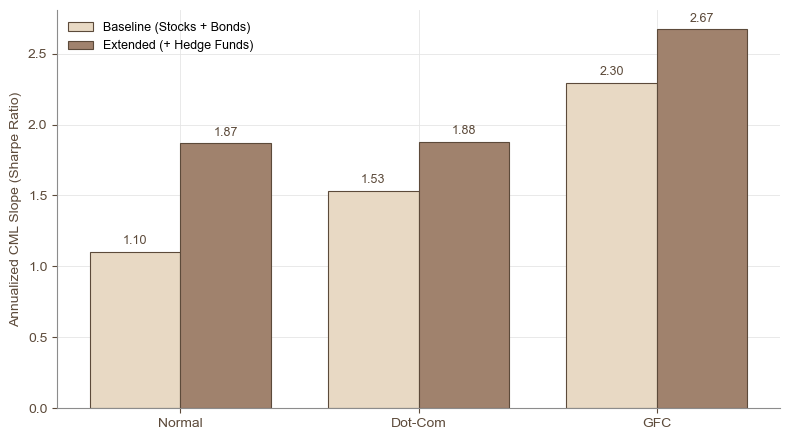

Figure 1 saved: fig1_H1_cml_slopes.png


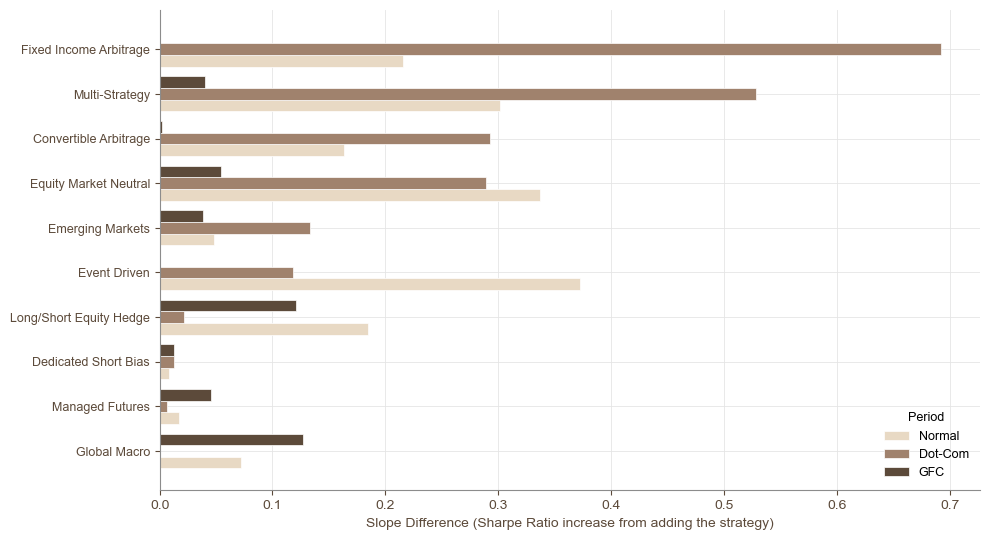

Figure 2 saved: fig2_H2_strategy_slopes.png


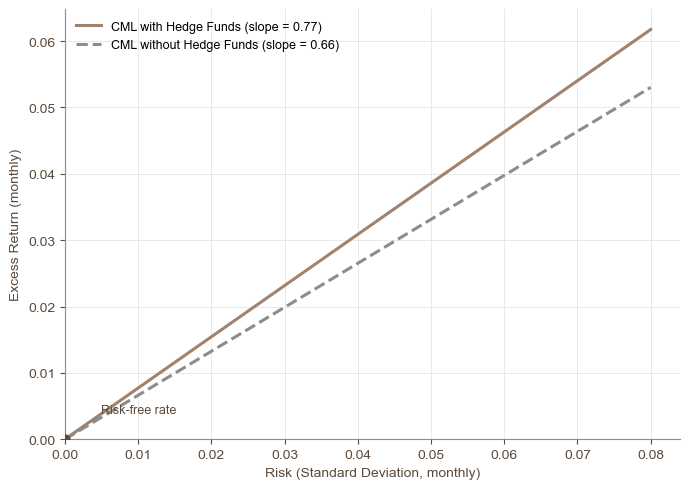

Figure 3 saved: fig3_CML_conceptual.png


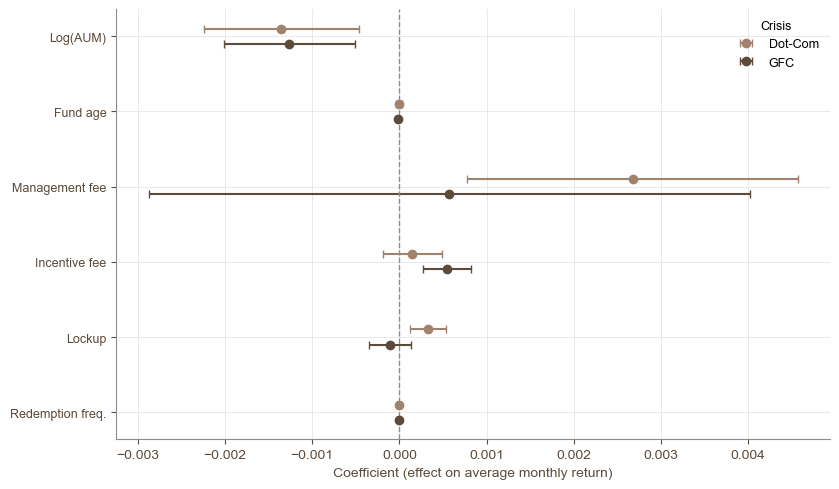

Figure 4 saved: fig4_H3_coefficients.png

All 4 figures generated and saved as PNG (300 dpi)


In [26]:
# ============================================================
# GENERATE THESIS FIGURES - ESMT STYLE (tan/beige, minimalist)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ---------- ESMT STYLE SETTINGS ----------
ESMT_PRIMARY   = '#A0826D'   # tan/beige primary
ESMT_SECONDARY = '#E8D9C4'   # light beige secondary
ESMT_DARK      = '#5C4A3A'   # dark brown for text/accents
ESMT_GRAY      = '#8C8C8C'   # neutral gray

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Calibri', 'Arial', 'DejaVu Sans']
mpl.rcParams['axes.edgecolor'] = ESMT_GRAY
mpl.rcParams['axes.linewidth'] = 0.8
mpl.rcParams['axes.grid'] = True
mpl.rcParams['grid.color'] = '#E5E5E5'
mpl.rcParams['grid.linewidth'] = 0.6
mpl.rcParams['axes.axisbelow'] = True

DPI = 300

# ============================================================
# FIGURE 1: H1 - Baseline vs Extended CML Slopes (annualized)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 4.5))

periods = h1_slopes['Period'].tolist()
baseline = h1_slopes['Baseline_Sharpe_Ann'].values
extended = h1_slopes['Extended_Sharpe_Ann'].values

x = np.arange(len(periods))
width = 0.38

bars1 = ax.bar(x - width/2, baseline, width, label='Baseline (Stocks + Bonds)',
               color=ESMT_SECONDARY, edgecolor=ESMT_DARK, linewidth=0.8)
bars2 = ax.bar(x + width/2, extended, width, label='Extended (+ Hedge Funds)',
               color=ESMT_PRIMARY, edgecolor=ESMT_DARK, linewidth=0.8)

# Value labels on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9, color=ESMT_DARK)

ax.set_ylabel('Annualized CML Slope (Sharpe Ratio)', fontsize=10, color=ESMT_DARK)
ax.set_xticks(x)
ax.set_xticklabels(periods, fontsize=10)
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=ESMT_DARK)
plt.tight_layout()
plt.savefig('fig1_H1_cml_slopes.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 1 saved: fig1_H1_cml_slopes.png")

# ============================================================
# FIGURE 2: H2 - Strategy Slope Differences across periods
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5.5))

# Pivot: strategies as rows, periods as columns
pivot = h2_slopes.pivot(index='Strategy', columns='Period', values='Slope_Difference')
pivot = pivot[['Normal', 'Dot-Com', 'GFC']]
# Sort by Dot-Com to make the pattern visible
pivot = pivot.sort_values('Dot-Com', ascending=True)

strategies = pivot.index.tolist()
y = np.arange(len(strategies))
height = 0.26

colors_period = {'Normal': ESMT_SECONDARY, 'Dot-Com': ESMT_PRIMARY, 'GFC': ESMT_DARK}
for i, period in enumerate(['Normal', 'Dot-Com', 'GFC']):
    ax.barh(y + (i-1)*height, pivot[period].values, height,
            label=period, color=colors_period[period],
            edgecolor='white', linewidth=0.5)

ax.set_xlabel('Slope Difference (Sharpe Ratio increase from adding the strategy)',
              fontsize=10, color=ESMT_DARK)
ax.set_yticks(y)
ax.set_yticklabels(strategies, fontsize=9)
ax.legend(frameon=False, fontsize=9, title='Period', title_fontsize=9, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=ESMT_DARK)
plt.tight_layout()
plt.savefig('fig2_H2_strategy_slopes.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 2 saved: fig2_H2_strategy_slopes.png")

# ============================================================
# FIGURE 3: Conceptual Capital Market Line (using GFC extended as example)
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))

rf = 0.0  # risk-free anchored at origin for illustration (excess return space)
# Use the extended universe tangency for GFC as the illustrative example
slope_ext = h1_slopes.loc[h1_slopes['Period'] == 'GFC', 'Extended_Sharpe_M'].values[0]
slope_base = h1_slopes.loc[h1_slopes['Period'] == 'GFC', 'Baseline_Sharpe_M'].values[0]

sigma = np.linspace(0, 0.08, 100)
cml_ext = rf + slope_ext * sigma
cml_base = rf + slope_base * sigma

ax.plot(sigma, cml_ext, color=ESMT_PRIMARY, linewidth=2.2,
        label=f'CML with Hedge Funds (slope = {slope_ext:.2f})')
ax.plot(sigma, cml_base, color=ESMT_GRAY, linewidth=2.2, linestyle='--',
        label=f'CML without Hedge Funds (slope = {slope_base:.2f})')

# Mark the risk-free point
ax.scatter([0], [rf], color=ESMT_DARK, zorder=5, s=40)
ax.annotate('Risk-free rate', xy=(0, rf), xytext=(0.005, 0.004),
            fontsize=9, color=ESMT_DARK)

ax.set_xlabel('Risk (Standard Deviation, monthly)', fontsize=10, color=ESMT_DARK)
ax.set_ylabel('Excess Return (monthly)', fontsize=10, color=ESMT_DARK)
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=ESMT_DARK)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('fig3_CML_conceptual.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 3 saved: fig3_CML_conceptual.png")

# ============================================================
# FIGURE 4: H3 - Coefficient plot (Base regression, with 95% CI)
# ============================================================
fig, ax = plt.subplots(figsize=(8.5, 5))

# Use base spec, exclude intercept for clarity
base = h3_reg[(h3_reg['spec'] == 'Base') & (h3_reg['variable'] != 'const')].copy()
name_map = {
    'log_AUM': 'Log(AUM)', 'age_months': 'Fund age',
    'mgmt_fee': 'Management fee', 'incentive_fee': 'Incentive fee',
    'lockup': 'Lockup', 'frequency': 'Redemption freq.'
}

variables = ['log_AUM', 'age_months', 'mgmt_fee', 'incentive_fee', 'lockup', 'frequency']
y_pos = np.arange(len(variables))

for i, crisis in enumerate(['DotCom', 'GFC']):
    offset = (i - 0.5) * 0.2
    coefs, ci_low, ci_high = [], [], []
    for var in variables:
        row = base[(base['crisis'] == crisis) & (base['variable'] == var)]
        coefs.append(row['coef'].values[0])
        ci_low.append(row['coef'].values[0] - row['ci_low'].values[0])
        ci_high.append(row['ci_high'].values[0] - row['coef'].values[0])
    color = ESMT_PRIMARY if crisis == 'DotCom' else ESMT_DARK
    label = 'Dot-Com' if crisis == 'DotCom' else 'GFC'
    ax.errorbar(coefs, y_pos + offset, xerr=[ci_low, ci_high], fmt='o',
                color=color, label=label, capsize=3, markersize=6, linewidth=1.5)

ax.axvline(0, color=ESMT_GRAY, linestyle='--', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels([name_map[v] for v in variables], fontsize=9)
ax.set_xlabel('Coefficient (effect on average monthly return)', fontsize=10, color=ESMT_DARK)
ax.legend(frameon=False, fontsize=9, title='Crisis', title_fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=ESMT_DARK)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig4_H3_coefficients.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 4 saved: fig4_H3_coefficients.png")

print("\n" + "=" * 60)
print("All 4 figures generated and saved as PNG (300 dpi)")
print("=" * 60)

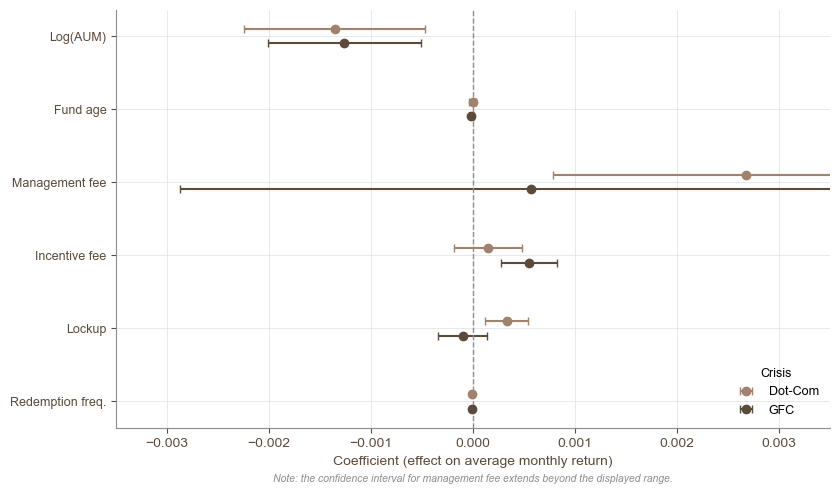

Figure 4 re-saved with trimmed x-axis.


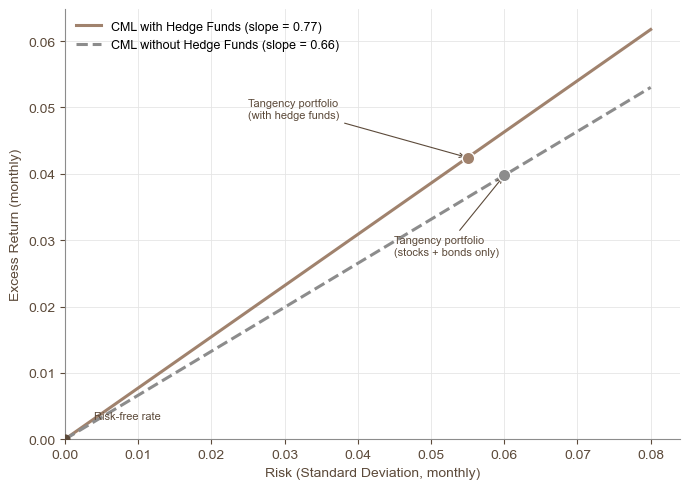

Figure 3 re-saved with tangency portfolio points.


In [27]:
# ============================================================
# RE-DO FIGURE 4: H3 Coefficient plot with TRIMMED x-axis
# ============================================================
fig, ax = plt.subplots(figsize=(8.5, 5))

base = h3_reg[(h3_reg['spec'] == 'Base') & (h3_reg['variable'] != 'const')].copy()
name_map = {
    'log_AUM': 'Log(AUM)', 'age_months': 'Fund age',
    'mgmt_fee': 'Management fee', 'incentive_fee': 'Incentive fee',
    'lockup': 'Lockup', 'frequency': 'Redemption freq.'
}
variables = ['log_AUM', 'age_months', 'mgmt_fee', 'incentive_fee', 'lockup', 'frequency']
y_pos = np.arange(len(variables))

# X-axis limits: trim to focus on the meaningful range
X_MIN, X_MAX = -0.0035, 0.0035

for i, crisis in enumerate(['DotCom', 'GFC']):
    offset = (i - 0.5) * 0.2
    coefs, ci_low, ci_high = [], [], []
    clipped_flags = []
    for var in variables:
        row = base[(base['crisis'] == crisis) & (base['variable'] == var)]
        c = row['coef'].values[0]
        lo = row['ci_low'].values[0]
        hi = row['ci_high'].values[0]
        coefs.append(c)
        ci_low.append(c - lo)
        ci_high.append(hi - c)
        # Flag if the CI extends beyond the trimmed axis
        clipped_flags.append(hi > X_MAX or lo < X_MIN)
    color = ESMT_PRIMARY if crisis == 'DotCom' else ESMT_DARK
    label = 'Dot-Com' if crisis == 'DotCom' else 'GFC'
    ax.errorbar(coefs, y_pos + offset, xerr=[ci_low, ci_high], fmt='o',
                color=color, label=label, capsize=3, markersize=6,
                linewidth=1.5, clip_on=True)

ax.axvline(0, color=ESMT_GRAY, linestyle='--', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels([name_map[v] for v in variables], fontsize=9)
ax.set_xlabel('Coefficient (effect on average monthly return)', fontsize=10, color=ESMT_DARK)
ax.set_xlim(X_MIN, X_MAX)
ax.legend(frameon=False, fontsize=9, title='Crisis', title_fontsize=9, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=ESMT_DARK)
ax.invert_yaxis()

# Note that management fee CI extends beyond the visible range
ax.text(0.5, -0.13,
        'Note: the confidence interval for management fee extends beyond the displayed range.',
        transform=ax.transAxes, ha='center', fontsize=7.5,
        color=ESMT_GRAY, style='italic')

plt.tight_layout()
plt.savefig('fig4_H3_coefficients.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 4 re-saved with trimmed x-axis.")

# ============================================================
# RE-DO FIGURE 3: CML with tangency portfolio points
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))

rf = 0.0
# GFC slopes and tangency portfolio risk/return for illustration
slope_ext = h1_slopes.loc[h1_slopes['Period'] == 'GFC', 'Extended_Sharpe_M'].values[0]
slope_base = h1_slopes.loc[h1_slopes['Period'] == 'GFC', 'Baseline_Sharpe_M'].values[0]

sigma = np.linspace(0, 0.08, 100)
cml_ext = rf + slope_ext * sigma
cml_base = rf + slope_base * sigma

# Plot the CML lines
ax.plot(sigma, cml_ext, color=ESMT_PRIMARY, linewidth=2.2,
        label=f'CML with Hedge Funds (slope = {slope_ext:.2f})')
ax.plot(sigma, cml_base, color=ESMT_GRAY, linewidth=2.2, linestyle='--',
        label=f'CML without Hedge Funds (slope = {slope_base:.2f})')

# Place illustrative tangency portfolio points
# (a representative risk level where each tangency portfolio sits)
sigma_tan_ext = 0.055
sigma_tan_base = 0.06
ax.scatter([sigma_tan_ext], [rf + slope_ext * sigma_tan_ext],
           color=ESMT_PRIMARY, s=80, zorder=5, edgecolor='white', linewidth=1)
ax.annotate('Tangency portfolio\n(with hedge funds)',
            xy=(sigma_tan_ext, rf + slope_ext * sigma_tan_ext),
            xytext=(sigma_tan_ext - 0.03, rf + slope_ext * sigma_tan_ext + 0.006),
            fontsize=8, color=ESMT_DARK,
            arrowprops=dict(arrowstyle='->', color=ESMT_DARK, lw=0.8))

ax.scatter([sigma_tan_base], [rf + slope_base * sigma_tan_base],
           color=ESMT_GRAY, s=80, zorder=5, edgecolor='white', linewidth=1)
ax.annotate('Tangency portfolio\n(stocks + bonds only)',
            xy=(sigma_tan_base, rf + slope_base * sigma_tan_base),
            xytext=(sigma_tan_base - 0.015, rf + slope_base * sigma_tan_base - 0.012),
            fontsize=8, color=ESMT_DARK,
            arrowprops=dict(arrowstyle='->', color=ESMT_DARK, lw=0.8))

# Risk-free point
ax.scatter([0], [rf], color=ESMT_DARK, zorder=5, s=40)
ax.annotate('Risk-free rate', xy=(0, rf), xytext=(0.004, 0.003),
            fontsize=8, color=ESMT_DARK)

ax.set_xlabel('Risk (Standard Deviation, monthly)', fontsize=10, color=ESMT_DARK)
ax.set_ylabel('Excess Return (monthly)', fontsize=10, color=ESMT_DARK)
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=ESMT_DARK)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('fig3_CML_conceptual.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 3 re-saved with tangency portfolio points.")

In [28]:
# ============================================================
# CELL 11: LONG-ONLY TANGENCY + ANNUAL REBALANCING FUNCTIONS
# (New main specification per supervisor feedback)
# ============================================================
from scipy.optimize import minimize

def compute_tangency_long_only(returns_df, rf_series):
    """
    Long-only tangency portfolio: maximize Sharpe subject to
    weights >= 0 and sum(weights) = 1. Numerical optimization (SLSQP).
    Returns (weights, sharpe_monthly).
    """
    excess = returns_df.sub(rf_series, axis=0).dropna()
    mu = excess.mean().values
    cov = excess.cov().values
    n = len(mu)

    def neg_sharpe(w):
        port_mu = w @ mu
        port_sd = np.sqrt(w @ cov @ w)
        if port_sd <= 0:
            return 1e6
        return -port_mu / port_sd

    w0 = np.ones(n) / n  # start from equal weights
    bounds = [(0.0, 1.0)] * n
    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1.0}]

    res = minimize(neg_sharpe, w0, method='SLSQP',
                   bounds=bounds, constraints=constraints,
                   options={'maxiter': 500, 'ftol': 1e-10})

    weights = res.x
    sharpe = -res.fun
    return weights, sharpe


def build_rebalanced_series(period_df, asset_cols, rf_col, block_len=12):
    """
    Annual rebalancing: split the period's months chronologically into
    blocks of `block_len`. Within each block, compute the long-only
    tangency weights from that block's returns and build the realized
    portfolio return series. Returns (portfolio_returns, excess_returns,
    weights_per_block).
    """
    d = period_df.sort_index()
    n_months = len(d)
    port_returns = []
    weights_log = []

    for start in range(0, n_months, block_len):
        block = d.iloc[start:start + block_len]
        if len(block) < 3:
            # Too few months to estimate moments; reuse previous weights
            if weights_log:
                w = weights_log[-1][1]
            else:
                w = np.ones(len(asset_cols)) / len(asset_cols)
        else:
            w, _ = compute_tangency_long_only(block[asset_cols], block[rf_col])
        weights_log.append((block.index[0], w))
        block_port = block[asset_cols].values @ w
        port_returns.append(pd.Series(block_port, index=block.index))

    port = pd.concat(port_returns)
    excess = port - d[rf_col]
    return port, excess, weights_log


# ---------- SANITY CHECK on the GFC period ----------
test_period = PERIOD_DATA['GFC']
baseline_assets = [EQUITY, BOND]

port, excess, wlog = build_rebalanced_series(test_period, baseline_assets, RF, block_len=12)
sharpe_realized = excess.mean() / excess.std()

print("SANITY CHECK - GFC baseline (long-only, 12-month blocks)")
print(f"  Months in period: {len(test_period)}")
print(f"  Blocks formed: {len(wlog)}")
for date, w in wlog:
    w_str = ", ".join(f"{a}={wi:.2f}" for a, wi in zip(baseline_assets, w))
    print(f"    Block starting {date.strftime('%Y-%m')}: {w_str}")
print(f"  Realized monthly Sharpe: {sharpe_realized:.4f}")

SANITY CHECK - GFC baseline (long-only, 12-month blocks)
  Months in period: 22
  Blocks formed: 2
    Block starting 2007-06: SP500=0.00, Bond_Return=1.00
    Block starting 2008-06: SP500=0.00, Bond_Return=1.00
  Realized monthly Sharpe: 0.3331


In [29]:
# ============================================================
# CELL 11b: PATCH build_rebalanced_series - absorb short remainder
# ============================================================

def build_rebalanced_series(period_df, asset_cols, rf_col, block_len=12, min_tail=6):
    """
    Annual rebalancing with remainder absorption: months are split into
    blocks of `block_len`; if the final block would have fewer than
    `min_tail` months, it is merged into the previous block.
    """
    d = period_df.sort_index()
    n_months = len(d)

    # Build block boundaries with tail absorption
    starts = list(range(0, n_months, block_len))
    if len(starts) > 1 and (n_months - starts[-1]) < min_tail:
        starts = starts[:-1]  # merge the short tail into the previous block

    port_returns = []
    weights_log = []
    for i, start in enumerate(starts):
        end = starts[i + 1] if i + 1 < len(starts) else n_months
        block = d.iloc[start:end]
        w, _ = compute_tangency_long_only(block[asset_cols], block[rf_col])
        weights_log.append((block.index[0], w))
        block_port = block[asset_cols].values @ w
        port_returns.append(pd.Series(block_port, index=block.index))

    port = pd.concat(port_returns)
    excess = port - d[rf_col]
    return port, excess, weights_log

print("Patched: short final blocks are now absorbed into the previous block.")
print("Normal (217 months) will now form 18 blocks (17x12 + 1x13).")

Patched: short final blocks are now absorbed into the previous block.
Normal (217 months) will now form 18 blocks (17x12 + 1x13).


In [30]:
# ============================================================
# CELL 12: H1 UNDER NEW MAIN SPEC (LONG-ONLY, ANNUAL REBALANCING)
# ============================================================

BASELINE_ASSETS = [EQUITY, BOND]
EXTENDED_ASSETS = [EQUITY, BOND, HF_AGGREGATE]
N_BOOT = 10000

def bootstrap_sharpe_diff_realized(excess_base, excess_ext, n_boot=N_BOOT, seed=RANDOM_SEED):
    """
    Paired bootstrap on the realized excess return series.
    Resamples months jointly for both universes to preserve correlation,
    recomputes the Sharpe difference each time.
    """
    rng = np.random.default_rng(seed)
    b_vals = excess_base.values
    e_vals = excess_ext.values
    n = len(b_vals)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        b = b_vals[idx]
        e = e_vals[idx]
        diffs[i] = (e.mean() / e.std(ddof=1)) - (b.mean() / b.std(ddof=1))
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    p_value = (diffs <= 0).mean()
    return ci_low, ci_high, p_value

h1_new_rows = []
h1_new_weights = {}

for period_name, pdata in PERIOD_DATA.items():
    # Baseline universe (long-only, annual blocks)
    port_b, exc_b, wlog_b = build_rebalanced_series(pdata, BASELINE_ASSETS, RF, block_len=12)
    sharpe_b = exc_b.mean() / exc_b.std(ddof=1)

    # Extended universe
    port_e, exc_e, wlog_e = build_rebalanced_series(pdata, EXTENDED_ASSETS, RF, block_len=12)
    sharpe_e = exc_e.mean() / exc_e.std(ddof=1)

    diff = sharpe_e - sharpe_b
    ci_low, ci_high, p_val = bootstrap_sharpe_diff_realized(exc_b, exc_e)

    h1_new_rows.append({
        'Period':            period_name,
        'N_months':          len(pdata),
        'N_blocks':          len(wlog_b),
        'Baseline_Sharpe_M': sharpe_b,
        'Extended_Sharpe_M': sharpe_e,
        'Difference':        diff,
        'Baseline_Ann':      sharpe_b * np.sqrt(12),
        'Extended_Ann':      sharpe_e * np.sqrt(12),
        'CI_Low':            ci_low,
        'CI_High':           ci_high,
        'P_Value':           p_val,
        'Significant_5pct':  ci_low > 0
    })
    h1_new_weights[period_name] = {'baseline': wlog_b, 'extended': wlog_e}

h1_new_df = pd.DataFrame(h1_new_rows)

print("=" * 80)
print("H1 - NEW MAIN SPECIFICATION (long-only, 12-month rebalancing)")
print("=" * 80)
print(h1_new_df.round(4).to_string(index=False))

print("\n" + "=" * 80)
print("EXTENDED UNIVERSE WEIGHTS PER BLOCK (SP500 / Bond / HF_All)")
print("=" * 80)
for period_name in PERIOD_DATA.keys():
    print(f"\n{period_name}:")
    for date, w in h1_new_weights[period_name]['extended']:
        w_str = " / ".join(f"{wi:.2f}" for wi in w)
        print(f"  Block {date.strftime('%Y-%m')}: {w_str}")

H1 - NEW MAIN SPECIFICATION (long-only, 12-month rebalancing)
 Period  N_months  N_blocks  Baseline_Sharpe_M  Extended_Sharpe_M  Difference  Baseline_Ann  Extended_Ann    CI_Low  CI_High  P_Value  Significant_5pct
 Normal       217        18           0.396000           0.630800    0.234800      1.371900      2.185200  0.132400 0.356900 0.000000              True
Dot-Com        32         3           0.412500           0.475400    0.062900      1.429000      1.646900 -0.264800 0.440100 0.335500             False
    GFC        22         2           0.333100           0.370400    0.037200      1.154000      1.283100 -0.124300 0.248600 0.309900             False

EXTENDED UNIVERSE WEIGHTS PER BLOCK (SP500 / Bond / HF_All)

Normal:
  Block 1993-02: 0.09 / 0.02 / 0.89
  Block 1994-02: 1.00 / 0.00 / 0.00
  Block 1995-02: 0.17 / 0.22 / 0.61
  Block 1996-02: 0.00 / 0.00 / 1.00
  Block 1997-02: 0.01 / 0.77 / 0.21
  Block 1998-02: 0.19 / 0.81 / 0.00
  Block 1999-02: 0.00 / 0.00 / 1.00
  Block 

In [31]:
# ============================================================
# CELL 13: H2 UNDER NEW MAIN SPEC (LONG-ONLY, ANNUAL REBALANCING)
# ============================================================

h2_new_rows = []

for period_name, pdata in PERIOD_DATA.items():
    # Baseline realized series (same for all strategies in this period)
    _, exc_b, _ = build_rebalanced_series(pdata, BASELINE_ASSETS, RF, block_len=12)
    sharpe_b = exc_b.mean() / exc_b.std(ddof=1)

    for strat in STRATEGIES_10:
        ext_assets = [EQUITY, BOND, strat]
        _, exc_e, wlog_e = build_rebalanced_series(pdata, ext_assets, RF, block_len=12)
        sharpe_e = exc_e.mean() / exc_e.std(ddof=1)
        diff = sharpe_e - sharpe_b
        ci_low, ci_high, p_val = bootstrap_sharpe_diff_realized(exc_b, exc_e)

        # Average weight the strategy receives across blocks
        avg_w_strat = np.mean([w[2] for _, w in wlog_e])

        h2_new_rows.append({
            'Period':           period_name,
            'Strategy':         strat,
            'Baseline_Sharpe':  sharpe_b,
            'Extended_Sharpe':  sharpe_e,
            'Difference':       diff,
            'Avg_Weight_Strat': avg_w_strat,
            'CI_Low':           ci_low,
            'CI_High':          ci_high,
            'P_Value':          p_val,
            'Significant_5pct': ci_low > 0
        })

h2_new_df = pd.DataFrame(h2_new_rows)

print("=" * 80)
print("H2 - NEW MAIN SPECIFICATION (long-only, annual rebalancing)")
print("=" * 80)
for period_name in PERIOD_DATA.keys():
    sub = h2_new_df[h2_new_df['Period'] == period_name].sort_values('Difference', ascending=False)
    print(f"\n----- {period_name} -----")
    print(sub[['Strategy', 'Difference', 'Avg_Weight_Strat', 'CI_Low', 'CI_High',
               'P_Value', 'Significant_5pct']].round(4).to_string(index=False))

# Summary: significant strategies per period
print("\n" + "=" * 80)
print("SIGNIFICANT STRATEGIES (95% bootstrap CI above zero)")
print("=" * 80)
for period_name in PERIOD_DATA.keys():
    sig = h2_new_df[(h2_new_df['Period'] == period_name) & (h2_new_df['Significant_5pct'])]
    names = sig.sort_values('Difference', ascending=False)['Strategy'].tolist()
    print(f"{period_name}: {len(names)}/10 -> {', '.join(names) if names else 'none'}")

H2 - NEW MAIN SPECIFICATION (long-only, annual rebalancing)

----- Normal -----
               Strategy  Difference  Avg_Weight_Strat    CI_Low  CI_High  P_Value  Significant_5pct
           Event Driven    0.541100          0.728600  0.406300 0.692000 0.000000              True
  Equity Market Neutral    0.395000          0.812500  0.260600 0.540400 0.000000              True
 Fixed Income Arbitrage    0.323700          0.723200  0.175700 0.490000 0.000000              True
         Multi-Strategy    0.296100          0.680800  0.162600 0.467700 0.000000              True
       Emerging Markets    0.215600          0.529500  0.090600 0.346500 0.000400              True
Long/Short Equity Hedge    0.194300          0.568500  0.112800 0.292000 0.000000              True
  Convertible Arbitrage    0.187200          0.610500  0.060000 0.352700 0.001600              True
           Global Macro    0.078400          0.380800  0.012700 0.154200 0.009600              True
        Managed Futu

In [32]:
# ============================================================
# REBUILD H3 BASE with the ORIGINAL documented recipe
# (exact match with thesis text: 237,992 obs / 3,243 funds)
# ============================================================

exclude_cats = ['Fund of Funds', 'Undefined', 'CTA', 'Options Strategy']

h3 = tass[~tass['primarycategory'].isin(exclude_cats)].copy()
h3 = h3.dropna(subset=['ROR'])
h3 = h3[h3['backfill_dummy'] == 0]
h3['inceptiondate'] = pd.to_datetime(h3['inceptiondate'], errors='coerce')

print(f"H3 base realigned: {len(h3):,} obs | {h3['ref'].nunique():,} funds")
print(f"Target:            237,992 obs | 3,243 funds")
print(f"Match: {len(h3) == 237992 and h3['ref'].nunique() == 3243}")

# Rebuild the crisis characteristic datasets on the aligned base
datasets = {}
for name, (start, end) in CRISIS_WINDOWS.items():
    datasets[name] = build_crisis_dataset(h3, start, end, name)
    print(f"{name}: {len(datasets[name])} funds with >= {MIN_MONTHS} months in the window")


H3 base realigned: 237,992 obs | 3,243 funds
Target:            237,992 obs | 3,243 funds
Match: True
DotCom: 1058 funds with >= 6 months in the window
GFC: 1612 funds with >= 6 months in the window


In [33]:
# ============================================================
# CELL 14: NEW H3 - FUND-LEVEL CML SLOPE CONTRIBUTIONS
# For each fund: universe {SP500, Bond, fund}, long-only tangency,
# slope difference vs baseline on the same months. Per supervisor.
# ============================================================

PRECRISIS_LEN = 12   # months before crisis start for past perf/vol
MIN_PRECRISIS = 6    # min pre-crisis months required

# Benchmarks on a year-month index for safe alignment with TASS dates
bench = df[[EQUITY, BOND, RF]].copy()
bench.index = bench.index.to_period('M')

def fund_slope_contribution(fund_series):
    """fund_series: fund monthly returns indexed by Period('M')."""
    aligned = bench.join(fund_series.rename('FUND'), how='inner').dropna()
    if len(aligned) < MIN_MONTHS:
        return None
    if aligned['FUND'].std(ddof=1) == 0:
        return None
    try:
        _, s_b = compute_tangency_long_only(aligned[[EQUITY, BOND]], aligned[RF])
        w_e, s_e = compute_tangency_long_only(aligned[[EQUITY, BOND, 'FUND']], aligned[RF])
    except Exception:
        return None
    return {'slope_diff': s_e - s_b, 'sharpe_base': s_b,
            'sharpe_ext': s_e, 'weight_fund': w_e[2], 'n_matched': len(aligned)}

h3_new_data = {}

for name, (start, end) in CRISIS_WINDOWS.items():
    start_ts, end_ts = pd.Timestamp(start), pd.Timestamp(end)
    pre_start = start_ts - pd.DateOffset(months=PRECRISIS_LEN)

    # Fund-month returns within the crisis window
    win = h3[(h3['refdate'] >= start_ts) & (h3['refdate'] <= end_ts)]
    win_groups = {fid: g for fid, g in win.groupby('ref')}

    # Pre-crisis stats (12 months before crisis start)
    pre = h3[(h3['refdate'] >= pre_start) & (h3['refdate'] < start_ts)]
    pre_stats = pre.groupby('ref')['ROR'].agg(['mean', 'std', 'count'])

    rows = []
    skipped_opt, skipped_pre = 0, 0
    for _, char_row in datasets[name].iterrows():
        fid = char_row['ref']
        g = win_groups.get(fid)
        if g is None:
            continue
        fund_ser = g.set_index(g['refdate'].dt.to_period('M'))['ROR']

        contrib = fund_slope_contribution(fund_ser)
        if contrib is None:
            skipped_opt += 1
            continue

        # Pre-crisis performance and volatility
        if fid in pre_stats.index and pre_stats.loc[fid, 'count'] >= MIN_PRECRISIS:
            pre_ret = pre_stats.loc[fid, 'mean']
            pre_vol = pre_stats.loc[fid, 'std']
        else:
            skipped_pre += 1
            pre_ret, pre_vol = np.nan, np.nan

        rows.append({
            'ref': fid,
            'primarycategory': char_row['primarycategory'],
            'slope_diff':   contrib['slope_diff'],
            'weight_fund':  contrib['weight_fund'],
            'n_matched':    contrib['n_matched'],
            'AUM':          char_row['AUM'],
            'age_months':   char_row['age_months'],
            'mgmt_fee':     char_row['mgmt_fee'],
            'incentive_fee': char_row['incentive_fee'],
            'lockup':       char_row['lockup'],
            'frequency':    char_row['frequency'],
            'pre_return':   pre_ret,
            'pre_vol':      pre_vol,
        })

    h3_new_data[name] = pd.DataFrame(rows)
    d = h3_new_data[name]
    print(f"===== {name} =====")
    print(f"  Funds with slope contribution computed: {len(d)}")
    print(f"  Skipped (optimization/alignment issues): {skipped_opt}")
    print(f"  Funds lacking pre-crisis history (pre_return = NaN): {skipped_pre}")
    print(f"  Slope difference distribution:")
    print(d['slope_diff'].describe().round(4).to_string())
    print(f"  Funds with zero weight in tangency: {(d['weight_fund'] < 0.001).sum()} "
          f"({(d['weight_fund'] < 0.001).mean()*100:.0f}%)")
    print()

===== DotCom =====
  Funds with slope contribution computed: 1058
  Skipped (optimization/alignment issues): 0
  Funds lacking pre-crisis history (pre_return = NaN): 449
  Slope difference distribution:
count   1058.000000
mean       0.156400
std        0.467300
min       -0.000000
25%        0.000000
50%        0.017100
75%        0.165200
max        8.019800
  Funds with zero weight in tangency: 398 (38%)

===== GFC =====
  Funds with slope contribution computed: 1611
  Skipped (optimization/alignment issues): 1
  Funds lacking pre-crisis history (pre_return = NaN): 367
  Slope difference distribution:
count   1611.000000
mean       0.126400
std        0.681000
min       -0.000000
25%       -0.000000
50%        0.000000
75%        0.042000
max       18.318600
  Funds with zero weight in tangency: 984 (61%)



In [34]:
# ============================================================
# CELL 15: NEW H3 - CROSS-SECTIONAL REGRESSIONS
# Dependent variable: fund-level slope difference
# ============================================================

def run_h3_new_regression(dframe, crisis_name):
    d = dframe.copy()
    d['log_AUM'] = np.log(d['AUM'].where(d['AUM'] > 0))

    y_var = 'slope_diff'
    x_vars = ['log_AUM', 'age_months', 'mgmt_fee', 'incentive_fee',
              'lockup', 'frequency', 'pre_return', 'pre_vol']

    reg_data = d[[y_var] + x_vars].dropna()
    y = reg_data[y_var]
    X = sm.add_constant(reg_data[x_vars])
    model = sm.OLS(y, X).fit(cov_type='HC1')

    print("=" * 70)
    print(f"NEW H3 REGRESSION - {crisis_name}")
    print(f"Dependent variable: fund-level CML slope contribution")
    print(f"Funds used: {len(reg_data)} (out of {len(d)})")
    print("=" * 70)
    print(model.summary().tables[1])
    print(f"R-squared: {model.rsquared:.4f}  |  Adj: {model.rsquared_adj:.4f}\n")
    return model, reg_data

models_h3_new = {}
reg_h3_new = {}
for name in ['DotCom', 'GFC']:
    models_h3_new[name], reg_h3_new[name] = run_h3_new_regression(h3_new_data[name], name)

NEW H3 REGRESSION - DotCom
Dependent variable: fund-level CML slope contribution
Funds used: 472 (out of 1058)
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.3182      0.244      1.303      0.193      -0.161       0.797
log_AUM          -0.0037      0.010     -0.361      0.718      -0.024       0.017
age_months       -0.0007      0.000     -2.259      0.024      -0.001   -9.36e-05
mgmt_fee         -0.0104      0.014     -0.724      0.469      -0.039       0.018
incentive_fee    -0.0007      0.002     -0.426      0.670      -0.004       0.003
lockup            0.0016      0.002      0.760      0.447      -0.002       0.006
frequency         0.0002      0.000      1.131      0.258      -0.000       0.000
pre_return       -0.0238      0.411     -0.058      0.954      -0.829       0.781
pre_vol          -1.6346      0.643     -2.540      0.011      -2.896

In [35]:
# ============================================================
# CELL 16: NEW H3 - ROBUSTNESS CHECKS
# (1) Winsorized dependent variable p1-p99
# (2) Without log_AUM (recovers funds with missing AUM)
# (3) Quadratic in log_AUM
# ============================================================
from scipy.stats import mstats

BASE_X = ['log_AUM', 'age_months', 'mgmt_fee', 'incentive_fee',
          'lockup', 'frequency', 'pre_return', 'pre_vol']

def run_spec(dframe, crisis_name, spec):
    d = dframe.copy()
    d['log_AUM'] = np.log(d['AUM'].where(d['AUM'] > 0))
    d['log_AUM_sq'] = d['log_AUM'] ** 2

    if spec == 'Winsorized':
        x_vars = BASE_X
    elif spec == 'No_AUM':
        x_vars = [v for v in BASE_X if v != 'log_AUM']
    elif spec == 'Quadratic_AUM':
        x_vars = BASE_X + ['log_AUM_sq']

    reg_data = d[['slope_diff'] + x_vars].dropna().copy()

    if spec == 'Winsorized':
        reg_data['y'] = mstats.winsorize(reg_data['slope_diff'], limits=[0.01, 0.01])
    else:
        reg_data['y'] = reg_data['slope_diff']

    model = sm.OLS(reg_data['y'], sm.add_constant(reg_data[x_vars])).fit(cov_type='HC1')

    print("=" * 70)
    print(f"{crisis_name} - {spec}  |  N = {len(reg_data)}  |  R2 = {model.rsquared:.4f}")
    print("=" * 70)
    print(model.summary().tables[1])
    print()
    return model

models_h3_robust = {}
for name in ['DotCom', 'GFC']:
    for spec in ['Winsorized', 'No_AUM', 'Quadratic_AUM']:
        models_h3_robust[(name, spec)] = run_spec(h3_new_data[name], name, spec)

DotCom - Winsorized  |  N = 472  |  R2 = 0.1230
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1103      0.094      1.175      0.240      -0.074       0.294
log_AUM           0.0041      0.005      0.837      0.402      -0.006       0.014
age_months       -0.0005      0.000     -2.515      0.012      -0.001      -0.000
mgmt_fee          0.0023      0.007      0.312      0.755      -0.012       0.017
incentive_fee    -0.0014      0.002     -0.895      0.371      -0.005       0.002
lockup            0.0030      0.002      1.951      0.051   -1.44e-05       0.006
frequency         0.0003   9.83e-05      2.616      0.009    6.45e-05       0.000
pre_return       -0.3135      0.257     -1.218      0.223      -0.818       0.191
pre_vol          -1.0309      0.247     -4.176      0.000      -1.515      -0.547

DotCom - No_AUM  |  N = 593  |  R2 = 0.0430
     

In [36]:
# ============================================================
# CELL 17: DESCRIPTIVE STATISTICS FOR REGRESSION VARIABLES
# (New section in Chapter 3, per supervisor feedback)
# ============================================================

DESC_VARS = ['slope_diff', 'AUM', 'age_months', 'mgmt_fee', 'incentive_fee',
             'lockup', 'frequency', 'pre_return', 'pre_vol']

desc_tables = {}
for name in ['DotCom', 'GFC']:
    d = h3_new_data[name].copy()
    d['AUM'] = d['AUM'] / 1e6  # express AUM in USD millions for readability
    stats = d[DESC_VARS].describe(percentiles=[0.5]).T
    stats = stats[['count', 'mean', '50%', 'std', 'min', 'max']]
    stats.columns = ['N', 'Mean', 'Median', 'Std_Dev', 'Min', 'Max']
    stats['N'] = stats['N'].astype(int)
    desc_tables[name] = stats.round(4)
    print("=" * 75)
    print(f"DESCRIPTIVE STATISTICS - {name} sample (AUM in USD millions)")
    print("=" * 75)
    print(stats.round(4).to_string())
    print()

DESCRIPTIVE STATISTICS - DotCom sample (AUM in USD millions)
                  N      Mean    Median    Std_Dev        Min         Max
slope_diff     1058  0.156400  0.017100   0.467300  -0.000000    8.019800
AUM             795 69.046200 15.000000 258.441700   0.014600 5977.739800
age_months     1058 24.852600 13.961900  44.077000 -26.281200  276.018400
mgmt_fee       1057  1.390500  1.250000   0.690500   0.000000    7.000000
incentive_fee  1053 18.614100 20.000000   4.997600   0.000000   50.000000
lockup         1058  4.027400  0.000000   6.765300   0.000000   60.000000
frequency      1034 81.557100 90.000000  83.328700   1.000000  365.000000
pre_return      609  0.029600  0.018600   0.036400  -0.080300    0.299100
pre_vol         609  0.055000  0.042900   0.048900   0.001700    0.350800

DESCRIPTIVE STATISTICS - GFC sample (AUM in USD millions)
                  N       Mean    Median    Std_Dev        Min         Max
slope_diff     1611   0.126400  0.000000   0.681000  -0.000000   

In [37]:
# ============================================================
# CELL 17b: DESCRIPTIVE STATISTICS ON THE ESTIMATION SAMPLE
# (complete cases actually used in the base H3 regressions)
# ============================================================

DESC_VARS = ['slope_diff', 'AUM', 'age_months', 'mgmt_fee', 'incentive_fee',
             'lockup', 'frequency', 'pre_return', 'pre_vol']
REG_VARS = ['slope_diff', 'log_AUM', 'age_months', 'mgmt_fee', 'incentive_fee',
            'lockup', 'frequency', 'pre_return', 'pre_vol']

desc_tables = {}
for name in ['DotCom', 'GFC']:
    d = h3_new_data[name].copy()
    d['log_AUM'] = np.log(d['AUM'].where(d['AUM'] > 0))
    # Keep only complete cases = the base regression estimation sample
    est = d.dropna(subset=REG_VARS).copy()
    est['AUM'] = est['AUM'] / 1e6  # USD millions

    stats = est[DESC_VARS].describe(percentiles=[0.5]).T
    stats = stats[['count', 'mean', '50%', 'std', 'min', 'max']]
    stats.columns = ['N', 'Mean', 'Median', 'Std_Dev', 'Min', 'Max']
    stats['N'] = stats['N'].astype(int)
    desc_tables[name] = stats.round(4)

    print("=" * 75)
    print(f"DESCRIPTIVES - {name} ESTIMATION SAMPLE (N = {len(est)} funds, AUM in USD mn)")
    print("=" * 75)
    print(stats.round(4).to_string())
    # Sanity: age should now be non-negative
    print(f"\n  Min age check (should be >= 0): {est['age_months'].min():.1f} months\n")

DESCRIPTIVES - DotCom ESTIMATION SAMPLE (N = 472 funds, AUM in USD mn)
                 N       Mean    Median    Std_Dev       Min         Max
slope_diff     472   0.119900  0.005200   0.426900 -0.000000    8.019800
AUM            472 103.512500 27.790000 328.262000  0.014600 5977.739800
age_months     472  48.832800 38.436300  38.062400  5.979000  276.018400
mgmt_fee       472   1.370800  1.000000   0.807100  0.000000    7.000000
incentive_fee  472  18.961900 20.000000   4.641300  0.000000   50.000000
lockup         472   3.533900  0.000000   6.420100  0.000000   36.000000
frequency      472  89.771200 90.000000  93.699100  1.000000  365.000000
pre_return     472   0.029200  0.018300   0.036700 -0.080300    0.299100
pre_vol        472   0.055000  0.043300   0.049700  0.001700    0.350800

  Min age check (should be >= 0): 6.0 months

DESCRIPTIVES - GFC ESTIMATION SAMPLE (N = 813 funds, AUM in USD mn)
                 N       Mean    Median    Std_Dev       Min         Max
slope_diff 

In [38]:
# ============================================================
# DIAGNOSTIC: reproduce the documented sample (237,992 / 3,243)
# ============================================================

print("backfill_dummy value counts (raw TASS):")
print(tass['backfill_dummy'].value_counts(dropna=False))
print()

no_fof = tass[tass['primarycategory'] != 'Fund of Funds']
print(f"FoF excluded:                    {len(no_fof):,} obs | {no_fof['ref'].nunique():,} funds")

# Approach A: drop observations flagged as backfilled
a = no_fof[no_fof['backfill_dummy'] == 0]
print(f"A) + backfill_dummy == 0:        {len(a):,} obs | {a['ref'].nunique():,} funds")

a2 = a[a['ROR'].notna()]
print(f"A') + ROR not null:              {len(a2):,} obs | {a2['ref'].nunique():,} funds")

# Approach B: drop the first 12 reported months of each fund
b = (no_fof.sort_values(['ref', 'refdate'])
          .groupby('ref', group_keys=False)
          .apply(lambda g: g.iloc[12:]))
print(f"B) + first 12 months dropped:    {len(b):,} obs | {b['ref'].nunique():,} funds")

b2 = b[b['ROR'].notna()]
print(f"B') + ROR not null:              {len(b2):,} obs | {b2['ref'].nunique():,} funds")

print(f"\nTarget from thesis text:         237,992 obs | 3,243 funds")

backfill_dummy value counts (raw TASS):
backfill_dummy
0    346556
1      3064
Name: count, dtype: int64

FoF excluded:                    245,829 obs | 3,264 funds
A) + backfill_dummy == 0:        243,506 obs | 3,264 funds
A') + ROR not null:              239,395 obs | 3,264 funds
B) + first 12 months dropped:    207,249 obs | 3,081 funds
B') + ROR not null:              203,638 obs | 3,081 funds

Target from thesis text:         237,992 obs | 3,243 funds


/var/folders/yv/n06q5y_92jb7clbq32lrp3vm0000gn/T/ipykernel_55291/1258528389.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.iloc[12:]))


In [39]:
# ============================================================
# READ THE ORIGINAL CLEANING CODE from "Thesis Hedge Funds.ipynb"
# ============================================================
import json

keywords = ['Fund of Funds', 'backfill', 'iloc[12', 'head(12', '237', '12)',
            'clean', 'filter', 'drop', 'survivorship']

with open('Thesis Hedge Funds.ipynb', 'r', encoding='utf-8') as f:
    nb = json.load(f)

for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] != 'code':
        continue
    source = ''.join(cell['source'])
    if any(kw.lower() in source.lower() for kw in keywords):
        print("=" * 70)
        print(f"CELL {i}")
        print("=" * 70)
        print(source)
        print()

CELL 4
# ============================================
# DETAILED EXPLORATION OF TASS DATABASE
# ============================================

# 1. How many unique funds?
n_funds = df['ref'].nunique()
print(f"Unique funds: {n_funds}")

# 2. Date range
print(f"\nDate range: {df['refdate'].min()} to {df['refdate'].max()}")

# 3. Available strategies
print(f"\nStrategies (primarycategory):")
print(df['primarycategory'].value_counts())

# 4. Live vs dead funds
print(f"\nLive vs dead funds (alive):")
print(df.groupby('alive')['ref'].nunique())

# 5. Backfill dummy
print(f"\nBackfill dummy distribution:")
print(df['backfill_dummy'].value_counts())

# 6. Missing values in key variables
key_vars = ['ROR', 'AUM_Filled', 'managementfee', 'incentivefee', 
            'lockupperiod', 'redemptionnoticeperiod', 'primarycategory',
            'inceptiondate', 'minimuminvestment']
print(f"\nMissing values in key variables:")
for var in key_vars:
    missing = df[var].isna().sum()
    pct = missing / le

In [40]:
# ============================================================
# VERIFY ORIGINAL RECIPE + investigate backfill_dummy meaning
# ============================================================

# Replicate Cell 6 of "Thesis Hedge Funds.ipynb" exactly
exclude_cats = ['Fund of Funds', 'Undefined', 'CTA', 'Options Strategy']
step1 = tass[~tass['primarycategory'].isin(exclude_cats)].copy()
print(f"1) Exclude {exclude_cats}:")
print(f"   {len(step1):,} obs | {step1['ref'].nunique():,} funds")

step2 = step1.dropna(subset=['ROR'])
print(f"2) Drop missing ROR:        {len(step2):,} obs | {step2['ref'].nunique():,} funds")

step3 = step2[step2['backfill_dummy'] == 0]
print(f"3) Keep backfill_dummy==0:  {len(step3):,} obs | {step3['ref'].nunique():,} funds")
print(f"\nTarget from thesis text:    237,992 obs | 3,243 funds")
match = (len(step3) == 237992) and (step3['ref'].nunique() == 3243)
print(f"EXACT MATCH: {match}")

# --- What does backfill_dummy actually flag? ---
flagged = tass[tass['backfill_dummy'] == 1].copy()
print(f"\nFlagged observations: {len(flagged):,} across {flagged['ref'].nunique()} funds")

# Are flagged obs at the START of each fund's series?
first_dates = tass.groupby('ref')['refdate'].min().rename('fund_first_date')
flagged = flagged.merge(first_dates, on='ref')
months_from_start = ((flagged['refdate'] - flagged['fund_first_date']).dt.days / 30.44)
print(f"Flagged obs, months from fund's first observation:")
print(months_from_start.describe().round(1).to_string())

# Relation to dateaddedtotass (the listing date)
if 'dateaddedtotass' in tass.columns:
    flagged['dateaddedtotass'] = pd.to_datetime(flagged['dateaddedtotass'], errors='coerce')
    valid = flagged.dropna(subset=['dateaddedtotass'])
    before_listing = (valid['refdate'] < valid['dateaddedtotass']).mean()
    print(f"\nShare of flagged obs dated BEFORE the fund was added to TASS: {before_listing*100:.1f}%")

1) Exclude ['Fund of Funds', 'Undefined', 'CTA', 'Options Strategy']:
   244,383 obs | 3,243 funds
2) Drop missing ROR:        237,992 obs | 3,243 funds
3) Keep backfill_dummy==0:  237,992 obs | 3,243 funds

Target from thesis text:    237,992 obs | 3,243 funds
EXACT MATCH: True

Flagged observations: 3,064 across 2131 funds
Flagged obs, months from fund's first observation:
count   3064.000000
mean       0.300000
std        0.500000
min        0.000000
25%        0.000000
50%        0.000000
75%        0.900000
max        1.000000

Share of flagged obs dated BEFORE the fund was added to TASS: 99.0%


In [41]:
# ============================================================
# KEY CHECK: does the final sample contain pre-listing returns?
# ============================================================
final = tass[~tass['primarycategory'].isin(exclude_cats)].dropna(subset=['ROR']).copy()
final['dateaddedtotass'] = pd.to_datetime(final['dateaddedtotass'], errors='coerce')
final['performancestartdate'] = pd.to_datetime(final['performancestartdate'], errors='coerce')

valid = final.dropna(subset=['dateaddedtotass'])
pre_listing = valid['refdate'] < valid['dateaddedtotass']
print(f"Final sample obs with a valid listing date: {len(valid):,}")
print(f"Obs dated BEFORE the fund was added to TASS: {pre_listing.sum():,} "
      f"({pre_listing.mean()*100:.1f}%)")
print(f"Funds affected: {valid.loc[pre_listing, 'ref'].nunique():,}")

valid2 = final.dropna(subset=['performancestartdate'])
pre_perf = valid2['refdate'] < valid2['performancestartdate']
print(f"\nObs dated before performancestartdate: {pre_perf.sum():,} ({pre_perf.mean()*100:.1f}%)")

Final sample obs with a valid listing date: 205,574
Obs dated BEFORE the fund was added to TASS: 76,358 (37.1%)
Funds affected: 2,629

Obs dated before performancestartdate: 0 (0.0%)


In [42]:
# ============================================================
# CELL 18: SAVE ALL NEW RESULTS (new main specification)
# ============================================================

output_new = 'thesis_results_NEW_SPEC.xlsx'

# H3 new: collect base + robustness coefficients into one frame
h3_frames = []
for name in ['DotCom', 'GFC']:
    h3_frames.append(model_to_df(models_h3_new[name], name, 'Base'))
    for spec in ['Winsorized', 'No_AUM', 'Quadratic_AUM']:
        h3_frames.append(model_to_df(models_h3_robust[(name, spec)], name, spec))
h3_new_results = pd.concat(h3_frames, ignore_index=True)

with pd.ExcelWriter(output_new, engine='openpyxl') as writer:
    h1_new_df.to_excel(writer, sheet_name='H1_LongOnly_Rebal', index=False)
    h2_new_df.to_excel(writer, sheet_name='H2_LongOnly_Rebal', index=False)
    h3_new_results.to_excel(writer, sheet_name='H3_New_Regressions', index=False)
    h3_new_data['DotCom'].to_excel(writer, sheet_name='H3_DotCom_FundData', index=False)
    h3_new_data['GFC'].to_excel(writer, sheet_name='H3_GFC_FundData', index=False)
    desc_tables['DotCom'].to_excel(writer, sheet_name='Descriptives_DotCom')
    desc_tables['GFC'].to_excel(writer, sheet_name='Descriptives_GFC')

import os
size_kb = os.path.getsize(output_new) / 1024
print(f"All new results saved to: {output_new} ({size_kb:.0f} KB)")

All new results saved to: thesis_results_NEW_SPEC.xlsx (263 KB)


In [43]:
# ============================================================
# CELL 19: H3 ROBUSTNESS - EXCLUDING PRE-LISTING (BACKFILLED) MONTHS
# Following Jorion & Schwarz (2019): drop observations dated before
# the fund was added to TASS. Funds without a listing date keep all.
# ============================================================

h3_nobf = h3.copy()
h3_nobf['dateaddedtotass'] = pd.to_datetime(h3_nobf['dateaddedtotass'], errors='coerce')
has_listing = h3_nobf['dateaddedtotass'].notna()
keep = ~has_listing | (h3_nobf['refdate'] >= h3_nobf['dateaddedtotass'])
print(f"Dropping {(~keep).sum():,} pre-listing observations "
      f"({(~keep).mean()*100:.1f}% of the aligned sample)")
h3_nobf = h3_nobf[keep].copy()
print(f"No-backfill base: {len(h3_nobf):,} obs | {h3_nobf['ref'].nunique():,} funds\n")

# Rebuild characteristics datasets on the filtered base
datasets_nobf = {}
for name, (start, end) in CRISIS_WINDOWS.items():
    datasets_nobf[name] = build_crisis_dataset(h3_nobf, start, end, name)

# Rebuild fund-level slope contributions on the filtered base
h3_nobf_data = {}
for name, (start, end) in CRISIS_WINDOWS.items():
    start_ts, end_ts = pd.Timestamp(start), pd.Timestamp(end)
    pre_start = start_ts - pd.DateOffset(months=PRECRISIS_LEN)

    win = h3_nobf[(h3_nobf['refdate'] >= start_ts) & (h3_nobf['refdate'] <= end_ts)]
    win_groups = {fid: g for fid, g in win.groupby('ref')}
    pre = h3_nobf[(h3_nobf['refdate'] >= pre_start) & (h3_nobf['refdate'] < start_ts)]
    pre_stats = pre.groupby('ref')['ROR'].agg(['mean', 'std', 'count'])

    rows = []
    for _, char_row in datasets_nobf[name].iterrows():
        fid = char_row['ref']
        g = win_groups.get(fid)
        if g is None:
            continue
        fund_ser = g.set_index(g['refdate'].dt.to_period('M'))['ROR']
        contrib = fund_slope_contribution(fund_ser)
        if contrib is None:
            continue
        if fid in pre_stats.index and pre_stats.loc[fid, 'count'] >= MIN_PRECRISIS:
            pre_ret, pre_vol = pre_stats.loc[fid, 'mean'], pre_stats.loc[fid, 'std']
        else:
            pre_ret, pre_vol = np.nan, np.nan
        rows.append({
            'ref': fid, 'slope_diff': contrib['slope_diff'],
            'AUM': char_row['AUM'], 'age_months': char_row['age_months'],
            'mgmt_fee': char_row['mgmt_fee'], 'incentive_fee': char_row['incentive_fee'],
            'lockup': char_row['lockup'], 'frequency': char_row['frequency'],
            'pre_return': pre_ret, 'pre_vol': pre_vol,
        })
    h3_nobf_data[name] = pd.DataFrame(rows)
    print(f"{name} (no backfill): {len(h3_nobf_data[name])} funds with slope contribution")

print()
models_h3_nobf = {}
for name in ['DotCom', 'GFC']:
    models_h3_nobf[name], _ = run_h3_new_regression(h3_nobf_data[name], f"{name} (NO BACKFILL)")

Dropping 76,358 pre-listing observations (32.1% of the aligned sample)
No-backfill base: 161,634 obs | 3,140 funds

DotCom (no backfill): 643 funds with slope contribution
GFC (no backfill): 1276 funds with slope contribution

NEW H3 REGRESSION - DotCom (NO BACKFILL)
Dependent variable: fund-level CML slope contribution
Funds used: 194 (out of 643)
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.5036      0.671      0.750      0.453      -0.812       1.819
log_AUM          -0.0104      0.029     -0.364      0.716      -0.066       0.046
age_months       -0.0018      0.001     -2.106      0.035      -0.003      -0.000
mgmt_fee         -0.0190      0.053     -0.360      0.719      -0.122       0.084
incentive_fee     0.0003      0.003      0.087      0.930      -0.006       0.007
lockup            0.0069      0.003      2.062      0.039       0.000      

In [44]:
# ============================================================
# CELL 19b: APPEND NO-BACKFILL RESULTS TO THE EXCEL
# ============================================================
nobf_frames = [model_to_df(models_h3_nobf[n], n, 'No_Backfill') for n in ['DotCom', 'GFC']]
h3_nobf_results = pd.concat(nobf_frames, ignore_index=True)

with pd.ExcelWriter('thesis_results_NEW_SPEC.xlsx', engine='openpyxl',
                    mode='a', if_sheet_exists='replace') as writer:
    h3_nobf_results.to_excel(writer, sheet_name='H3_NoBackfill', index=False)
print("No-backfill results appended to thesis_results_NEW_SPEC.xlsx")

No-backfill results appended to thesis_results_NEW_SPEC.xlsx


In [45]:
# ============================================================
# CELL 20: FINAL THESIS TABLES (new main specification)
# ============================================================

VAR_NAMES = {'const': 'Intercept', 'log_AUM': 'Log(AUM)', 'age_months': 'Fund age (months)',
             'mgmt_fee': 'Management fee', 'incentive_fee': 'Incentive fee',
             'lockup': 'Lockup (months)', 'frequency': 'Redemption freq. (days)',
             'pre_return': 'Pre-crisis return', 'pre_vol': 'Pre-crisis volatility'}

# ---- Table 1: Descriptive statistics (both crises stacked) ----
t1_parts = []
for name, label in [('DotCom', 'Dot-Com'), ('GFC', 'GFC')]:
    part = desc_tables[name].copy()
    part.insert(0, 'Sample', label)
    part.insert(1, 'Variable', part.index)
    t1_parts.append(part.reset_index(drop=True))
t1 = pd.concat(t1_parts, ignore_index=True)

# ---- Table 2: H1 main spec + unconstrained comparison ----
t2 = h1_new_df[['Period', 'N_months', 'N_blocks', 'Baseline_Sharpe_M', 'Extended_Sharpe_M',
                'Difference', 'CI_Low', 'CI_High', 'P_Value', 'Significant_5pct']].round(4)
t2_unc = h1_df[['Period', 'Baseline_Sharpe_M', 'Extended_Sharpe_M', 'Slope_Difference_M']].round(4)
t2_unc.columns = ['Period', 'Unconstrained_Baseline', 'Unconstrained_Extended', 'Unconstrained_Diff']

# ---- Table 3: H2 main spec ----
t3 = h2_new_df[['Period', 'Strategy', 'Difference', 'Avg_Weight_Strat',
                'CI_Low', 'CI_High', 'P_Value', 'Significant_5pct']].round(4)

# ---- Table 4: H3 base regressions side by side ----
rows = []
base = h3_new_results[h3_new_results['spec'] == 'Base']
for var in base['variable'].unique():
    dc = base[(base['crisis'] == 'DotCom') & (base['variable'] == var)]
    gf = base[(base['crisis'] == 'GFC') & (base['variable'] == var)]
    rows.append({'Variable': VAR_NAMES.get(var, var),
                 'DotCom coef': round(dc['coef'].values[0], 5),
                 'DotCom p': round(dc['p_value'].values[0], 3),
                 'GFC coef': round(gf['coef'].values[0], 5),
                 'GFC p': round(gf['p_value'].values[0], 3)})
t4 = pd.DataFrame(rows)
for crisis, col in [('DotCom', 'DotCom coef'), ('GFC', 'GFC coef')]:
    sub = base[base['crisis'] == crisis]
    t4 = pd.concat([t4, pd.DataFrame([
        {'Variable': 'N (funds)', col: int(sub['n_obs'].iloc[0])},
        {'Variable': 'R-squared', col: round(sub['r_squared'].iloc[0], 4)}])],
        ignore_index=True)

# ---- Table 5: H3 robustness summary (key coefficients, all 5 specs) ----
all_h3 = pd.concat([h3_new_results, h3_nobf_results], ignore_index=True)
t5_rows = []
for crisis in ['DotCom', 'GFC']:
    for spec in ['Base', 'Winsorized', 'No_AUM', 'Quadratic_AUM', 'No_Backfill']:
        sub = all_h3[(all_h3['crisis'] == crisis) & (all_h3['spec'] == spec)]
        if len(sub) == 0:
            continue
        row = {'Crisis': crisis, 'Spec': spec, 'N': int(sub['n_obs'].iloc[0]),
               'R2': round(sub['r_squared'].iloc[0], 4)}
        for var in ['pre_vol', 'age_months', 'incentive_fee', 'lockup']:
            v = sub[sub['variable'] == var]
            row[var] = round(v['coef'].values[0], 5) if len(v) else '—'
            row[f'{var}_p'] = round(v['p_value'].values[0], 3) if len(v) else '—'
        t5_rows.append(row)
t5 = pd.DataFrame(t5_rows)

# ---- Save ----
with pd.ExcelWriter('thesis_TABLES_FINAL.xlsx', engine='openpyxl') as writer:
    t1.to_excel(writer, sheet_name='T1_Descriptives', index=False)
    t2.to_excel(writer, sheet_name='T2_H1_Main', index=False)
    t2_unc.to_excel(writer, sheet_name='T2b_H1_Unconstrained', index=False)
    t3.to_excel(writer, sheet_name='T3_H2_Strategies', index=False)
    t4.to_excel(writer, sheet_name='T4_H3_Base', index=False)
    t5.to_excel(writer, sheet_name='T5_H3_Robustness', index=False)

print("Final thesis tables saved to: thesis_TABLES_FINAL.xlsx")
print("\nT5 preview (H3 robustness summary):")
print(t5.to_string(index=False))

Final thesis tables saved to: thesis_TABLES_FINAL.xlsx

T5 preview (H3 robustness summary):
Crisis          Spec    N       R2   pre_vol  pre_vol_p  age_months  age_months_p  incentive_fee  incentive_fee_p    lockup  lockup_p
DotCom          Base  472 0.040200 -1.634570   0.011000   -0.000710      0.024000      -0.000750         0.670000  0.001560  0.447000
DotCom    Winsorized  472 0.123000 -1.030940   0.000000   -0.000480      0.012000      -0.001430         0.371000  0.002960  0.051000
DotCom        No_AUM  593 0.043000 -1.565730   0.000000   -0.000730      0.022000      -0.000440         0.792000  0.001720  0.326000
DotCom Quadratic_AUM  472 0.040200 -1.640230   0.011000   -0.000720      0.025000      -0.000710         0.685000  0.001560  0.448000
DotCom   No_Backfill  194 0.043000 -2.402630   0.157000   -0.001810      0.035000       0.000300         0.930000  0.006900  0.039000
   GFC          Base  813 0.027200 -2.431960   0.013000   -0.000420      0.254000       0.010620        

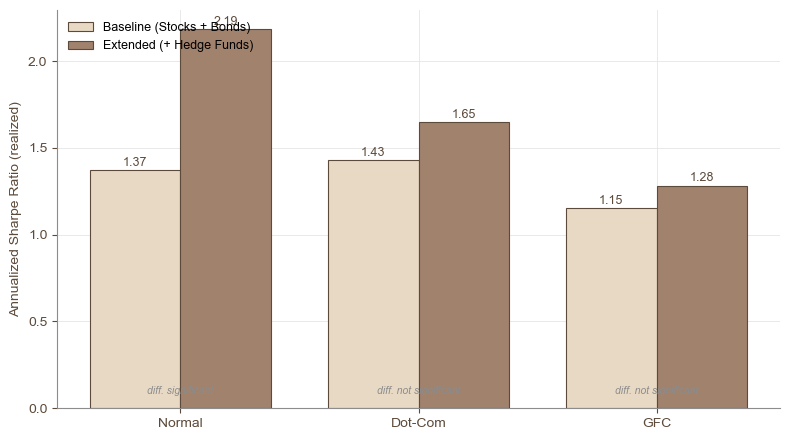

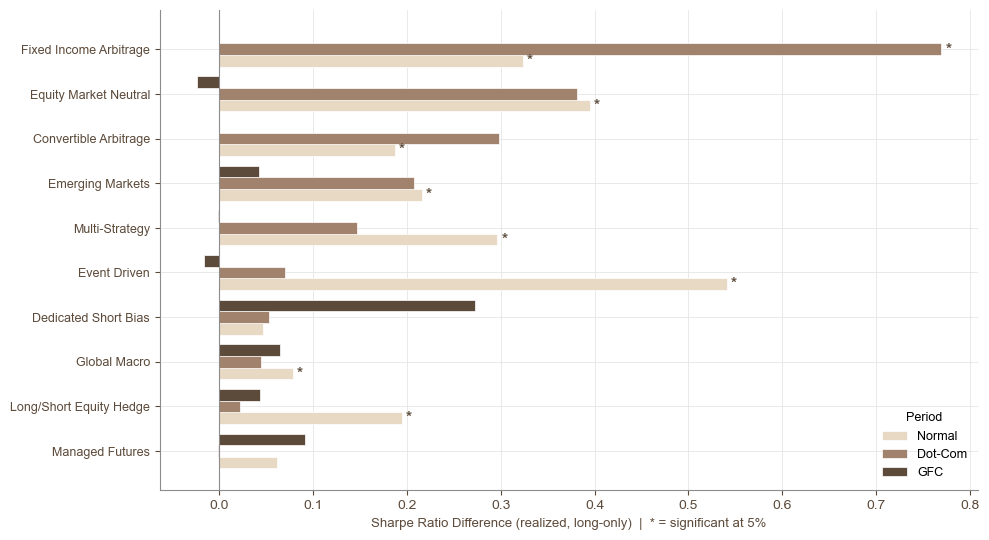

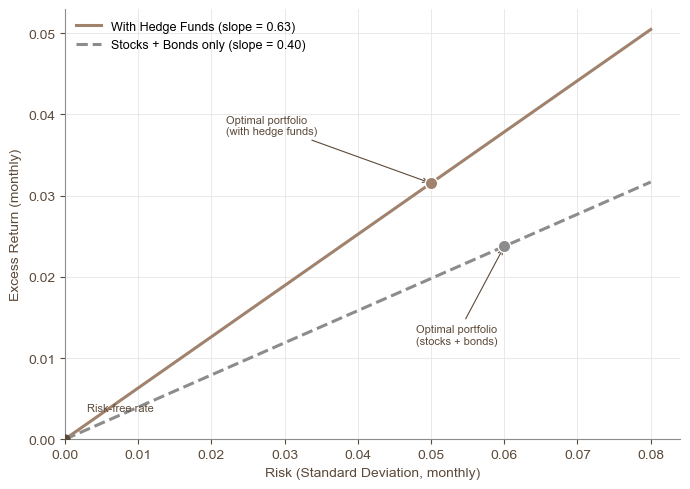

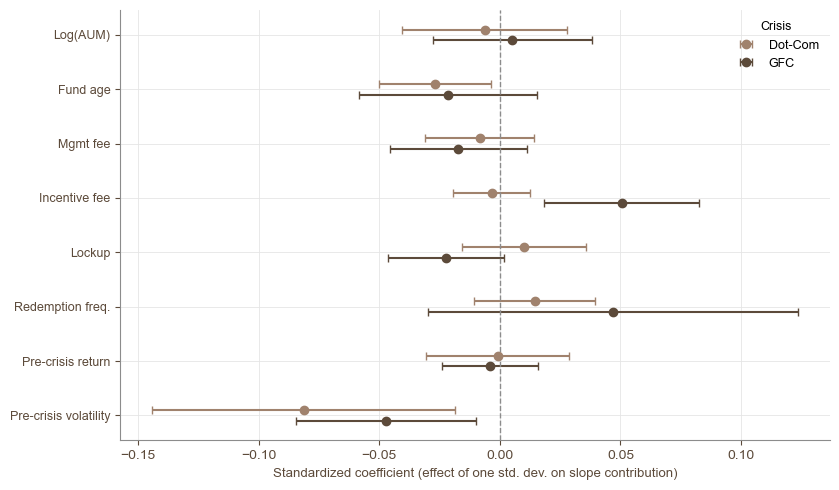

All 4 final figures saved: fig1_H1_final.png ... fig4_H3_final.png


In [46]:
# ============================================================
# CELL 21: FINAL THESIS FIGURES (new main specification)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib as mpl

ESMT_PRIMARY, ESMT_SECONDARY = '#A0826D', '#E8D9C4'
ESMT_DARK, ESMT_GRAY = '#5C4A3A', '#8C8C8C'
mpl.rcParams.update({'font.family': 'sans-serif',
                     'font.sans-serif': ['Calibri', 'Arial', 'DejaVu Sans'],
                     'axes.edgecolor': ESMT_GRAY, 'axes.linewidth': 0.8,
                     'axes.grid': True, 'grid.color': '#E5E5E5',
                     'grid.linewidth': 0.6, 'axes.axisbelow': True})
DPI = 300

# ---------- FIGURE 1: H1 (annualized, long-only annual rebalancing) ----------
fig, ax = plt.subplots(figsize=(8, 4.5))
periods = h1_new_df['Period'].tolist()
x = np.arange(len(periods)); width = 0.38
b1 = ax.bar(x - width/2, h1_new_df['Baseline_Ann'], width,
            label='Baseline (Stocks + Bonds)', color=ESMT_SECONDARY,
            edgecolor=ESMT_DARK, linewidth=0.8)
b2 = ax.bar(x + width/2, h1_new_df['Extended_Ann'], width,
            label='Extended (+ Hedge Funds)', color=ESMT_PRIMARY,
            edgecolor=ESMT_DARK, linewidth=0.8)
for bars in [b1, b2]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', fontsize=9, color=ESMT_DARK)
# Significance note per period
for i, row in h1_new_df.iterrows():
    tag = 'diff. significant' if row['Significant_5pct'] else 'diff. not significant'
    ax.annotate(tag, xy=(x[i], 0.08), ha='center', fontsize=7.5,
                color=ESMT_GRAY, style='italic')
ax.set_ylabel('Annualized Sharpe Ratio (realized)', fontsize=10, color=ESMT_DARK)
ax.set_xticks(x); ax.set_xticklabels(periods, fontsize=10)
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(colors=ESMT_DARK)
plt.tight_layout()
plt.savefig('fig1_H1_final.png', dpi=DPI, bbox_inches='tight'); plt.show()

# ---------- FIGURE 2: H2 strategy differences ----------
fig, ax = plt.subplots(figsize=(10, 5.5))
pivot = h2_new_df.pivot(index='Strategy', columns='Period', values='Difference')
pivot = pivot[['Normal', 'Dot-Com', 'GFC']].sort_values('Dot-Com')
sig = h2_new_df.pivot(index='Strategy', columns='Period', values='Significant_5pct').loc[pivot.index]
y = np.arange(len(pivot)); h = 0.26
colors = {'Normal': ESMT_SECONDARY, 'Dot-Com': ESMT_PRIMARY, 'GFC': ESMT_DARK}
for i, p in enumerate(['Normal', 'Dot-Com', 'GFC']):
    bars = ax.barh(y + (i-1)*h, pivot[p], h, label=p, color=colors[p],
                   edgecolor='white', linewidth=0.5)
    for j, bar in enumerate(bars):          # asterisk = significant
        if sig[p].iloc[j]:
            ax.annotate('*', xy=(bar.get_width(), bar.get_y() + bar.get_height()/2),
                        xytext=(3, -3), textcoords='offset points',
                        fontsize=11, color=ESMT_DARK, fontweight='bold')
ax.set_xlabel('Sharpe Ratio Difference (realized, long-only)  |  * = significant at 5%',
              fontsize=9.5, color=ESMT_DARK)
ax.set_yticks(y); ax.set_yticklabels(pivot.index, fontsize=9)
ax.legend(frameon=False, fontsize=9, title='Period', title_fontsize=9, loc='lower right')
ax.axvline(0, color=ESMT_GRAY, linewidth=0.8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(colors=ESMT_DARK)
plt.tight_layout()
plt.savefig('fig2_H2_final.png', dpi=DPI, bbox_inches='tight'); plt.show()

# ---------- FIGURE 3: CML conceptual (Normal period, new spec) ----------
fig, ax = plt.subplots(figsize=(7, 5))
s_b = h1_new_df.loc[h1_new_df['Period'] == 'Normal', 'Baseline_Sharpe_M'].values[0]
s_e = h1_new_df.loc[h1_new_df['Period'] == 'Normal', 'Extended_Sharpe_M'].values[0]
sig_x = np.linspace(0, 0.08, 100)
ax.plot(sig_x, s_e*sig_x, color=ESMT_PRIMARY, lw=2.2,
        label=f'With Hedge Funds (slope = {s_e:.2f})')
ax.plot(sig_x, s_b*sig_x, color=ESMT_GRAY, lw=2.2, ls='--',
        label=f'Stocks + Bonds only (slope = {s_b:.2f})')
for sx, sl, c, lbl, off in [(0.05, s_e, ESMT_PRIMARY, 'Optimal portfolio\n(with hedge funds)', (-0.028, 0.006)),
                            (0.06, s_b, ESMT_GRAY, 'Optimal portfolio\n(stocks + bonds)', (-0.012, -0.012))]:
    ax.scatter([sx], [sl*sx], color=c, s=80, zorder=5, edgecolor='white', lw=1)
    ax.annotate(lbl, xy=(sx, sl*sx), xytext=(sx+off[0], sl*sx+off[1]),
                fontsize=8, color=ESMT_DARK,
                arrowprops=dict(arrowstyle='->', color=ESMT_DARK, lw=0.8))
ax.scatter([0], [0], color=ESMT_DARK, s=40, zorder=5)
ax.annotate('Risk-free rate', xy=(0, 0), xytext=(0.003, 0.0035), fontsize=8, color=ESMT_DARK)
ax.set_xlabel('Risk (Standard Deviation, monthly)', fontsize=10, color=ESMT_DARK)
ax.set_ylabel('Excess Return (monthly)', fontsize=10, color=ESMT_DARK)
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(colors=ESMT_DARK); ax.set_xlim(left=0); ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('fig3_CML_final.png', dpi=DPI, bbox_inches='tight'); plt.show()

# ---------- FIGURE 4: H3 standardized coefficient plot ----------
X_VARS = ['log_AUM', 'age_months', 'mgmt_fee', 'incentive_fee',
          'lockup', 'frequency', 'pre_return', 'pre_vol']
NAMES = ['Log(AUM)', 'Fund age', 'Mgmt fee', 'Incentive fee',
         'Lockup', 'Redemption freq.', 'Pre-crisis return', 'Pre-crisis volatility']

def standardized_fit(dframe):
    d = dframe.copy()
    d['log_AUM'] = np.log(d['AUM'].where(d['AUM'] > 0))
    reg = d[['slope_diff'] + X_VARS].dropna()
    Xz = (reg[X_VARS] - reg[X_VARS].mean()) / reg[X_VARS].std(ddof=1)
    return sm.OLS(reg['slope_diff'], sm.add_constant(Xz)).fit(cov_type='HC1')

fig, ax = plt.subplots(figsize=(8.5, 5))
y = np.arange(len(X_VARS))
for i, (crisis, color, lbl) in enumerate([('DotCom', ESMT_PRIMARY, 'Dot-Com'),
                                          ('GFC', ESMT_DARK, 'GFC')]):
    m = standardized_fit(h3_new_data[crisis])
    coefs = m.params[X_VARS].values
    ci = m.conf_int().loc[X_VARS]
    err = [coefs - ci[0].values, ci[1].values - coefs]
    ax.errorbar(coefs, y + (i-0.5)*0.2, xerr=err, fmt='o', color=color,
                label=lbl, capsize=3, markersize=6, lw=1.5)
ax.axvline(0, color=ESMT_GRAY, ls='--', lw=1)
ax.set_yticks(y); ax.set_yticklabels(NAMES, fontsize=9)
ax.set_xlabel('Standardized coefficient (effect of one std. dev. on slope contribution)',
              fontsize=9.5, color=ESMT_DARK)
ax.legend(frameon=False, fontsize=9, title='Crisis', title_fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(colors=ESMT_DARK); ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig4_H3_final.png', dpi=DPI, bbox_inches='tight'); plt.show()

print("All 4 final figures saved: fig1_H1_final.png ... fig4_H3_final.png")

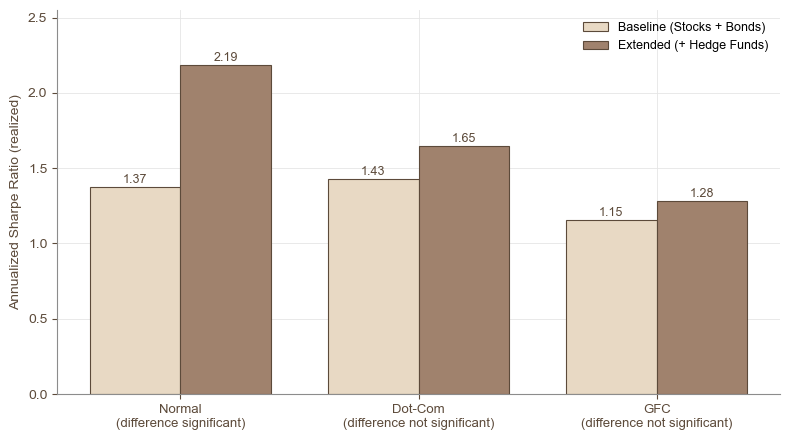

Figure 1 fixed and re-saved.


In [47]:
# ============================================================
# CELL 21b: FIX FIGURE 1 (legend collision + hidden notes)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 4.5))
periods = h1_new_df['Period'].tolist()
x = np.arange(len(periods)); width = 0.38

b1 = ax.bar(x - width/2, h1_new_df['Baseline_Ann'], width,
            label='Baseline (Stocks + Bonds)', color=ESMT_SECONDARY,
            edgecolor=ESMT_DARK, linewidth=0.8)
b2 = ax.bar(x + width/2, h1_new_df['Extended_Ann'], width,
            label='Extended (+ Hedge Funds)', color=ESMT_PRIMARY,
            edgecolor=ESMT_DARK, linewidth=0.8)
for bars in [b1, b2]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', fontsize=9, color=ESMT_DARK)

# Significance folded into the x-axis labels (always readable)
xlabels = []
for _, row in h1_new_df.iterrows():
    tag = 'difference significant' if row['Significant_5pct'] else 'difference not significant'
    xlabels.append(f"{row['Period']}\n({tag})")
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=9.5)

ax.set_ylabel('Annualized Sharpe Ratio (realized)', fontsize=10, color=ESMT_DARK)
ax.set_ylim(0, 2.55)                                   # headroom for the 2.19 bar
ax.legend(frameon=False, fontsize=9, loc='upper right')  # free space above GFC
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(colors=ESMT_DARK)
plt.tight_layout()
plt.savefig('fig1_H1_final.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Figure 1 fixed and re-saved.")

In [48]:
# ============================================================
# RENAME FIGURES BY FINAL ORDER IN THE DOCUMENT
# ============================================================
import shutil

renames = [
    ('fig3_CML_final.png', 'Figure1_CML_Section4-3.png'),
    ('fig1_H1_final.png',  'Figure2_H1_Section5-1.png'),
    ('fig2_H2_final.png',  'Figure3_H2_Section5-2.png'),
    ('fig4_H3_final.png',  'Figure4_H3_Section5-3.png'),
]

for old, new in renames:
    shutil.copy(old, new)
    print(f"  {old}  ->  {new}")

print("\nListo. Inserta en Word en este orden:")
print("  Figure1_CML_Section4-3.png  -> Capitulo 4, seccion 4.3")
print("  Figure2_H1_Section5-1.png   -> Seccion 5.1 (despues de Table 2)")
print("  Figure3_H2_Section5-2.png   -> Seccion 5.2")
print("  Figure4_H3_Section5-3.png   -> Seccion 5.3")

  fig3_CML_final.png  ->  Figure1_CML_Section4-3.png
  fig1_H1_final.png  ->  Figure2_H1_Section5-1.png
  fig2_H2_final.png  ->  Figure3_H2_Section5-2.png
  fig4_H3_final.png  ->  Figure4_H3_Section5-3.png

Listo. Inserta en Word en este orden:
  Figure1_CML_Section4-3.png  -> Capitulo 4, seccion 4.3
  Figure2_H1_Section5-1.png   -> Seccion 5.1 (despues de Table 2)
  Figure3_H2_Section5-2.png   -> Seccion 5.2
  Figure4_H3_Section5-3.png   -> Seccion 5.3


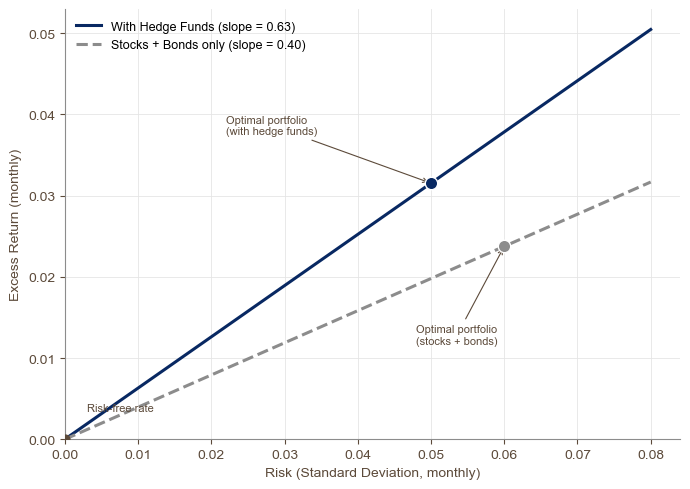

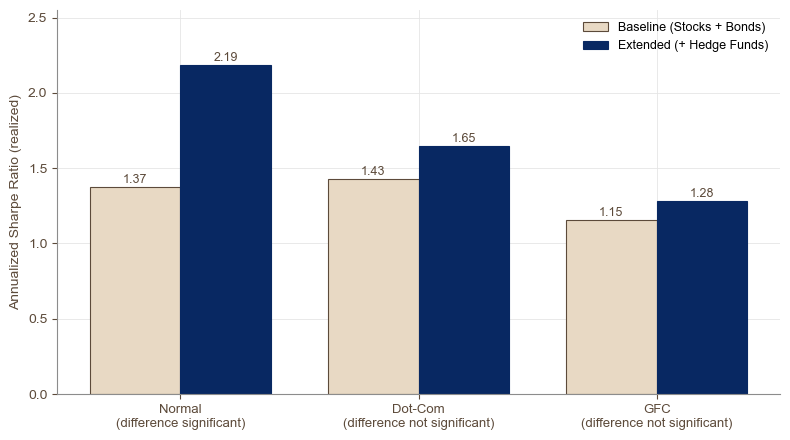

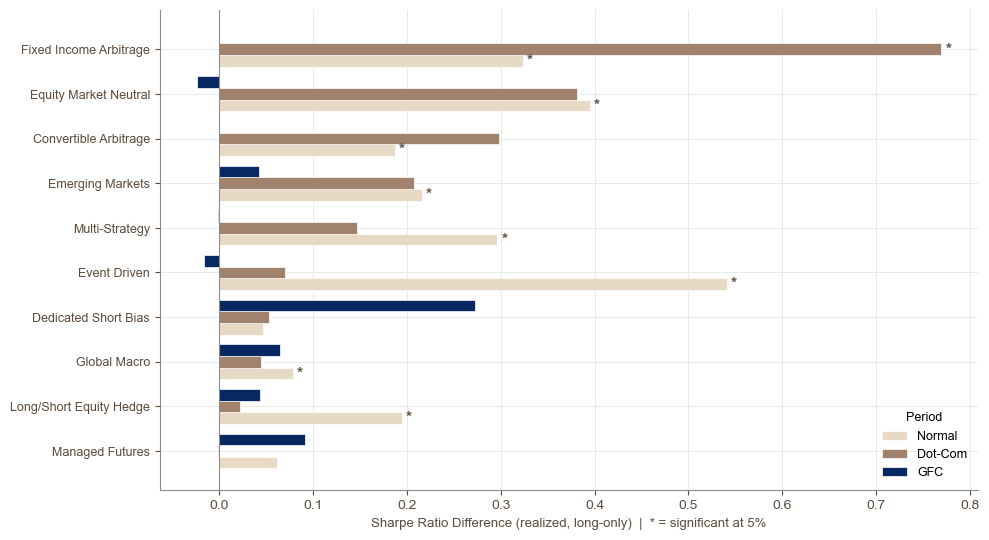

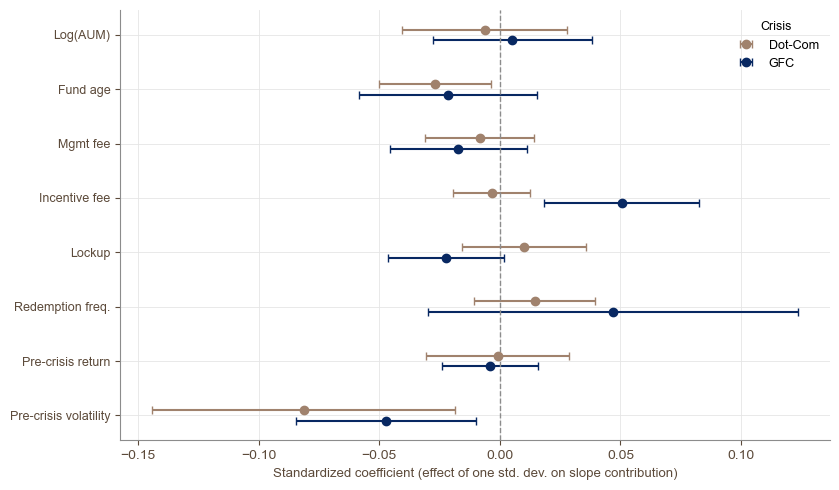

4 figures re-saved with ESMT navy accent, under final insertion names.


In [49]:
# ============================================================
# CELL 22: FINAL FIGURES WITH ESMT NAVY ACCENT (#082862)
# Saves directly under the final insertion filenames.
# ============================================================
ESMT_NAVY = '#082862'

# ---------- FIGURE 1 (doc): CML conceptual, Section 4.3 ----------
fig, ax = plt.subplots(figsize=(7, 5))
s_b = h1_new_df.loc[h1_new_df['Period'] == 'Normal', 'Baseline_Sharpe_M'].values[0]
s_e = h1_new_df.loc[h1_new_df['Period'] == 'Normal', 'Extended_Sharpe_M'].values[0]
sig_x = np.linspace(0, 0.08, 100)
ax.plot(sig_x, s_e*sig_x, color=ESMT_NAVY, lw=2.2,
        label=f'With Hedge Funds (slope = {s_e:.2f})')
ax.plot(sig_x, s_b*sig_x, color=ESMT_GRAY, lw=2.2, ls='--',
        label=f'Stocks + Bonds only (slope = {s_b:.2f})')
for sx, sl, c, lbl, off in [(0.05, s_e, ESMT_NAVY, 'Optimal portfolio\n(with hedge funds)', (-0.028, 0.006)),
                            (0.06, s_b, ESMT_GRAY, 'Optimal portfolio\n(stocks + bonds)', (-0.012, -0.012))]:
    ax.scatter([sx], [sl*sx], color=c, s=80, zorder=5, edgecolor='white', lw=1)
    ax.annotate(lbl, xy=(sx, sl*sx), xytext=(sx+off[0], sl*sx+off[1]),
                fontsize=8, color=ESMT_DARK,
                arrowprops=dict(arrowstyle='->', color=ESMT_DARK, lw=0.8))
ax.scatter([0], [0], color=ESMT_DARK, s=40, zorder=5)
ax.annotate('Risk-free rate', xy=(0, 0), xytext=(0.003, 0.0035), fontsize=8, color=ESMT_DARK)
ax.set_xlabel('Risk (Standard Deviation, monthly)', fontsize=10, color=ESMT_DARK)
ax.set_ylabel('Excess Return (monthly)', fontsize=10, color=ESMT_DARK)
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(colors=ESMT_DARK); ax.set_xlim(left=0); ax.set_ylim(bottom=0)
plt.tight_layout(); plt.savefig('Figure1_CML_Section4-3.png', dpi=DPI, bbox_inches='tight'); plt.show()

# ---------- FIGURE 2 (doc): H1 bars, Section 5.1 ----------
fig, ax = plt.subplots(figsize=(8, 4.5))
periods = h1_new_df['Period'].tolist()
x = np.arange(len(periods)); width = 0.38
b1 = ax.bar(x - width/2, h1_new_df['Baseline_Ann'], width,
            label='Baseline (Stocks + Bonds)', color=ESMT_SECONDARY,
            edgecolor=ESMT_DARK, linewidth=0.8)
b2 = ax.bar(x + width/2, h1_new_df['Extended_Ann'], width,
            label='Extended (+ Hedge Funds)', color=ESMT_NAVY,
            edgecolor=ESMT_NAVY, linewidth=0.8)
for bars in [b1, b2]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', fontsize=9, color=ESMT_DARK)
xlabels = [f"{row['Period']}\n({'difference significant' if row['Significant_5pct'] else 'difference not significant'})"
           for _, row in h1_new_df.iterrows()]
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=9.5)
ax.set_ylabel('Annualized Sharpe Ratio (realized)', fontsize=10, color=ESMT_DARK)
ax.set_ylim(0, 2.55)
ax.legend(frameon=False, fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(colors=ESMT_DARK)
plt.tight_layout(); plt.savefig('Figure2_H1_Section5-1.png', dpi=DPI, bbox_inches='tight'); plt.show()

# ---------- FIGURE 3 (doc): H2 strategies, Section 5.2 ----------
fig, ax = plt.subplots(figsize=(10, 5.5))
pivot = h2_new_df.pivot(index='Strategy', columns='Period', values='Difference')
pivot = pivot[['Normal', 'Dot-Com', 'GFC']].sort_values('Dot-Com')
sig = h2_new_df.pivot(index='Strategy', columns='Period', values='Significant_5pct').loc[pivot.index]
y = np.arange(len(pivot)); h = 0.26
colors = {'Normal': ESMT_SECONDARY, 'Dot-Com': ESMT_PRIMARY, 'GFC': ESMT_NAVY}
for i, p in enumerate(['Normal', 'Dot-Com', 'GFC']):
    bars = ax.barh(y + (i-1)*h, pivot[p], h, label=p, color=colors[p],
                   edgecolor='white', linewidth=0.5)
    for j, bar in enumerate(bars):
        if sig[p].iloc[j]:
            ax.annotate('*', xy=(bar.get_width(), bar.get_y() + bar.get_height()/2),
                        xytext=(3, -3), textcoords='offset points',
                        fontsize=11, color=ESMT_DARK, fontweight='bold')
ax.set_xlabel('Sharpe Ratio Difference (realized, long-only)  |  * = significant at 5%',
              fontsize=9.5, color=ESMT_DARK)
ax.set_yticks(y); ax.set_yticklabels(pivot.index, fontsize=9)
ax.legend(frameon=False, fontsize=9, title='Period', title_fontsize=9, loc='lower right')
ax.axvline(0, color=ESMT_GRAY, linewidth=0.8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(colors=ESMT_DARK)
plt.tight_layout(); plt.savefig('Figure3_H2_Section5-2.png', dpi=DPI, bbox_inches='tight'); plt.show()

# ---------- FIGURE 4 (doc): H3 standardized coefficients, Section 5.3 ----------
fig, ax = plt.subplots(figsize=(8.5, 5))
y = np.arange(len(X_VARS))
for i, (crisis, color, lbl) in enumerate([('DotCom', ESMT_PRIMARY, 'Dot-Com'),
                                          ('GFC', ESMT_NAVY, 'GFC')]):
    m = standardized_fit(h3_new_data[crisis])
    coefs = m.params[X_VARS].values
    ci = m.conf_int().loc[X_VARS]
    err = [coefs - ci[0].values, ci[1].values - coefs]
    ax.errorbar(coefs, y + (i-0.5)*0.2, xerr=err, fmt='o', color=color,
                label=lbl, capsize=3, markersize=6, lw=1.5)
ax.axvline(0, color=ESMT_GRAY, ls='--', lw=1)
ax.set_yticks(y); ax.set_yticklabels(NAMES, fontsize=9)
ax.set_xlabel('Standardized coefficient (effect of one std. dev. on slope contribution)',
              fontsize=9.5, color=ESMT_DARK)
ax.legend(frameon=False, fontsize=9, title='Crisis', title_fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(colors=ESMT_DARK); ax.invert_yaxis()
plt.tight_layout(); plt.savefig('Figure4_H3_Section5-3.png', dpi=DPI, bbox_inches='tight'); plt.show()

print("4 figures re-saved with ESMT navy accent, under final insertion names.")